<a href="https://colab.research.google.com/github/abhi6988/Group-7/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Objective

The objective of this project is to identify meaningful shopper segments from online grocery purchasing behaviour and understand how these segments differ in their reorder patterns.

The analysis uses the Instacart Online Grocery Shopping Dataset 2017 and applies unsupervised machine learning techniques including:

- Principal Component Analysis (PCA)
- K-Means Clustering
- Hierarchical Clustering
- Gaussian Mixture Models (GMM)
- Market Basket Analysis

The final objective is to translate the discovered customer segments into actionable business recommendations for personalized replenishment reminders, product recommendations, bundles and targeted marketing strategies.

In [4]:
# ============================================================
# GOOGLE COLAB SETUP
# ============================================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Project folder
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/ML Project"

# Change working directory
os.chdir(PROJECT_PATH)

print("Current working directory:")
print(os.getcwd())

print("\nFiles available:")
for file in sorted(os.listdir(PROJECT_PATH)):
    print(" -", file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory:
/content/drive/MyDrive/Colab Notebooks/ML Project

Files available:
 - ML Project.ipynb
 - aisles.csv
 - departments.csv
 - order_products__prior.csv
 - order_products__train.csv
 - orders.csv
 - products.csv


In [5]:
# ============================================================
# COLAB DATA ACCESS & ENVIRONMENT CHECK
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 70)
print("COLAB ENVIRONMENT CHECK")
print("=" * 70)

print("\nWorking directory:")
print(os.getcwd())

print("\nDataset files:")

dataset_files = [
    "aisles.csv",
    "departments.csv",
    "products.csv",
    "orders.csv",
    "order_products__train.csv",
    "order_products__prior.csv"
]

for file in dataset_files:

    path = os.path.join(PROJECT_PATH, file)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"✓ {file:<30} {size_mb:,.2f} MB")
    else:
        print(f"✗ {file:<30} NOT FOUND")

print("\n" + "=" * 70)
print("TESTING LARGE PRIOR-ORDERS FILE")
print("=" * 70)

prior_path = os.path.join(
    PROJECT_PATH,
    "order_products__prior.csv"
)

# Read only a small sample — does NOT load the 550 MB file
prior_test = pd.read_csv(
    prior_path,
    nrows=5
)

print("\nSuccessfully read order_products__prior.csv")

print("\nColumns:")
print(prior_test.columns.tolist())

print("\nFirst 5 rows:")
display(prior_test)

print("\n" + "=" * 70)
print("COLAB DATA ACCESS CHECK COMPLETED")
print("=" * 70)

COLAB ENVIRONMENT CHECK

Working directory:
/content/drive/MyDrive/Colab Notebooks/ML Project

Dataset files:
✓ aisles.csv                     0.00 MB
✓ departments.csv                0.00 MB
✓ products.csv                   2.07 MB
✓ orders.csv                     103.92 MB
✓ order_products__train.csv      23.54 MB
✓ order_products__prior.csv      550.80 MB

TESTING LARGE PRIOR-ORDERS FILE

Successfully read order_products__prior.csv

Columns:
['order_id', 'product_id', 'add_to_cart_order', 'reordered']

First 5 rows:


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0



COLAB DATA ACCESS CHECK COMPLETED


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:

import os

# Show the folder where Jupyter is currently running
current_folder = os.getcwd()

print("Jupyter working folder:")
print(current_folder)

print("\nFiles/folders available here:")
for item in os.listdir(current_folder):
    print(" -", item)

# ------------------------------------------------------------
# Expected Instacart files
# ------------------------------------------------------------

expected_files = [
    "aisles.csv",
    "departments.csv",
    "order_products__prior.csv",
    "order_products__train.csv",
    "orders.csv",
    "products.csv"
]

print("\n" + "="*60)
print("CHECKING INSTACART DATASET")
print("="*60)

all_found = True

for file in expected_files:
    file_path = os.path.join(current_folder, file)

    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 ** 2)
        print(f"✓ {file:<30} {size_mb:,.2f} MB")
    else:
        print(f"✗ {file:<30} NOT FOUND")
        all_found = False

print("="*60)

if all_found:
    print("All 6 dataset files found successfully.")
else:
    print("Some files are missing. We will fix the file path before continuing.")

Jupyter working folder:
/content/drive/MyDrive/Colab Notebooks/ML Project

Files/folders available here:
 - aisles.csv
 - departments.csv
 - order_products__prior.csv
 - order_products__train.csv
 - orders.csv
 - products.csv
 - ML Project.ipynb

CHECKING INSTACART DATASET
✓ aisles.csv                     0.00 MB
✓ departments.csv                0.00 MB
✓ order_products__prior.csv      550.80 MB
✓ order_products__train.csv      23.54 MB
✓ orders.csv                     103.92 MB
✓ products.csv                   2.07 MB
All 6 dataset files found successfully.


In [8]:
# ============================================================
# STEP 3: INSPECT DATASET STRUCTURE
# ============================================================

# Load the smaller datasets
aisles = pd.read_csv("aisles.csv")
departments = pd.read_csv("departments.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")

# ------------------------------------------------------------
# Display basic information
# ------------------------------------------------------------

datasets = {
    "aisles": aisles,
    "departments": departments,
    "products": products,
    "orders": orders
}

for name, df in datasets.items():
    print("\n" + "="*70)
    print(f"{name.upper()}")
    print("="*70)

    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())


AISLES
Shape: (134, 2)

Columns:
['aisle_id', 'aisle']

First 5 rows:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



DEPARTMENTS
Shape: (21, 2)

Columns:
['department_id', 'department']

First 5 rows:


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



PRODUCTS
Shape: (49688, 4)

Columns:
['product_id', 'product_name', 'aisle_id', 'department_id']

First 5 rows:


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



ORDERS
Shape: (3421083, 7)

Columns:
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

First 5 rows:


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


## 4. Understanding Customer Order Behaviour

The `orders.csv` file provides the relationship between customers and their orders. It contains information about:

- Customer identifier (`user_id`)
- Order identifier (`order_id`)
- Order sequence (`order_number`)
- Day of week (`order_dow`)
- Hour of day (`order_hour_of_day`)
- Days since the previous order (`days_since_prior_order`)
- Dataset partition (`eval_set`)

These variables are important for constructing behavioural features at the customer level.

The objective is not to cluster individual orders. Instead, order-level information will be aggregated to create a customer-level behavioural dataset suitable for unsupervised clustering.

In [9]:
# ============================================================
# STEP 4: PROFILE ORDERS DATA
# ============================================================

print("=" * 70)
print("ORDERS DATASET PROFILE")
print("=" * 70)

# Basic information
print("\nShape:")
print(orders.shape)

print("\nData types:")
print(orders.dtypes)

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("MISSING VALUES")
print("-" * 70)

missing = pd.DataFrame({
    "Missing_Count": orders.isnull().sum(),
    "Missing_Percentage": (orders.isnull().mean() * 100).round(2)
})

display(missing)

# ------------------------------------------------------------
# Unique values
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("UNIQUE VALUES")
print("-" * 70)

print("Unique users:", orders["user_id"].nunique())
print("Unique orders:", orders["order_id"].nunique())
print("Unique eval_set values:", orders["eval_set"].unique())

# ------------------------------------------------------------
# Evaluation set distribution
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("EVALUATION SET DISTRIBUTION")
print("-" * 70)

eval_counts = orders["eval_set"].value_counts()
eval_percent = orders["eval_set"].value_counts(normalize=True).mul(100).round(2)

eval_summary = pd.DataFrame({
    "Order_Count": eval_counts,
    "Percentage": eval_percent
})

display(eval_summary)

# ------------------------------------------------------------
# Order number summary
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ORDER NUMBER SUMMARY")
print("-" * 70)

display(orders["order_number"].describe())

# ------------------------------------------------------------
# Days since prior order summary
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("DAYS SINCE PRIOR ORDER SUMMARY")
print("-" * 70)

display(orders["days_since_prior_order"].describe())

# ------------------------------------------------------------
# First few rows
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SAMPLE RECORDS")
print("-" * 70)

display(orders.head(10))

ORDERS DATASET PROFILE

Shape:
(3421083, 7)

Data types:
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

----------------------------------------------------------------------
MISSING VALUES
----------------------------------------------------------------------


,Missing_Count,Missing_Percentage
order_id,0,0.00
user_id,0,0.00
eval_set,0,0.00
order_number,0,0.00
order_dow,0,0.00
order_hour_of_day,0,0.00
days_since_prior_order,206209,6.03



----------------------------------------------------------------------
UNIQUE VALUES
----------------------------------------------------------------------
Unique users: 206209
Unique orders: 3421083
Unique eval_set values: ['prior' 'train' 'test']

----------------------------------------------------------------------
EVALUATION SET DISTRIBUTION
----------------------------------------------------------------------


,Order_Count,Percentage
eval_set,,
prior,3214874,93.97
train,131209,3.84
test,75000,2.19



----------------------------------------------------------------------
ORDER NUMBER SUMMARY
----------------------------------------------------------------------


,order_number
count,3.421083e+06
mean,1.715486e+01
std,1.773316e+01
min,1.000000e+00
25%,5.000000e+00
50%,1.100000e+01
75%,2.300000e+01
max,1.000000e+02



----------------------------------------------------------------------
DAYS SINCE PRIOR ORDER SUMMARY
----------------------------------------------------------------------


,days_since_prior_order
count,3.214874e+06
mean,1.111484e+01
std,9.206737e+00
min,0.000000e+00
25%,4.000000e+00
50%,7.000000e+00
75%,1.500000e+01
max,3.000000e+01



----------------------------------------------------------------------
SAMPLE RECORDS
----------------------------------------------------------------------


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
5,3367565,1,prior,6,2,7,19.0
6,550135,1,prior,7,1,9,20.0
7,3108588,1,prior,8,1,14,14.0
8,2295261,1,prior,9,1,16,0.0
9,2550362,1,prior,10,4,8,30.0


## 5. Customer-Level Behavioural Features

To perform customer segmentation, order-level records must be transformed into a customer-level analytical dataset.

The following behavioural characteristics will be derived from historical orders:

- Order frequency
- Typical time between orders
- Median replenishment interval
- Minimum and maximum observed order gaps
- Typical shopping day
- Typical shopping hour

Only historical (`prior`) orders are used for the initial behavioural profiling. This helps ensure that the segmentation is based on observed historical behaviour rather than future evaluation records.

The `days_since_prior_order` variable requires special consideration. Its maximum value is 30 days, meaning intervals at 30 days may represent customers whose actual interval is 30 days or longer. Therefore, the value is treated as a censored upper-bound measure rather than an exact interval.

In [10]:
# ============================================================
# STEP 5: CREATE CUSTOMER-LEVEL ORDER BEHAVIOUR FEATURES
# ============================================================

# Use only historical prior orders
orders_prior = orders[orders["eval_set"] == "prior"].copy()

print("Prior orders shape:", orders_prior.shape)
print("Unique customers:", orders_prior["user_id"].nunique())

# ------------------------------------------------------------
# Aggregate order behaviour at customer level
# ------------------------------------------------------------

customer_order_features = (
    orders_prior
    .groupby("user_id")
    .agg(
        total_orders=("order_id", "count"),

        avg_days_between_orders=("days_since_prior_order", "mean"),

        median_days_between_orders=("days_since_prior_order", "median"),

        min_days_between_orders=("days_since_prior_order", "min"),

        max_days_between_orders=("days_since_prior_order", "max"),

        avg_order_dow=("order_dow", "mean"),

        avg_order_hour=("order_hour_of_day", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nCustomer-level feature dataset:")
print("Shape:", customer_order_features.shape)

display(customer_order_features.head(10))

print("\nFeature summary:")
display(customer_order_features.describe())

Prior orders shape: (3214874, 7)
Unique customers: 206209

Customer-level feature dataset:
Shape: (206209, 8)


,user_id,total_orders,avg_days_between_orders,median_days_between_orders,min_days_between_orders,max_days_between_orders,avg_order_dow,avg_order_hour
0,1,10,19.555556,20.0,0.0,30.0,2.500000,10.300000
1,2,14,15.230769,13.0,3.0,30.0,2.142857,10.571429
2,3,12,12.090909,11.0,7.0,21.0,1.083333,16.416667
3,4,5,13.750000,17.0,0.0,21.0,4.800000,12.600000
4,5,4,13.333333,11.0,10.0,19.0,1.750000,16.000000
5,6,3,9.000000,9.0,6.0,12.0,3.666667,17.333333
6,7,20,10.684211,7.0,2.0,30.0,1.850000,13.600000
7,8,3,30.000000,30.0,30.0,30.0,4.000000,2.666667
8,9,3,18.000000,18.0,6.0,30.0,2.000000,14.333333
9,10,5,19.750000,18.5,12.0,30.0,3.600000,16.600000



Feature summary:


,user_id,total_orders,avg_days_between_orders,median_days_between_orders,min_days_between_orders,max_days_between_orders,avg_order_dow,avg_order_hour
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,15.590367,15.209435,14.753522,6.472317,26.301582,2.753258,13.586213
std,59527.555167,16.654774,7.105277,8.676030,7.578506,6.654544,0.941419,2.110461
min,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51553.000000,5.000000,9.416667,7.000000,1.000000,25.000000,2.200000,12.222222
50%,103105.000000,9.000000,14.500000,13.000000,4.000000,30.000000,2.750000,13.571429
75%,154657.000000,19.000000,20.285714,21.500000,8.000000,30.000000,3.333333,15.000000
max,206209.000000,99.000000,30.000000,30.000000,30.000000,30.000000,6.000000,23.000000


## 6. Customer Product and Reorder Behaviour

The `order_products__prior.csv` file contains product-level information for historical orders, including whether a product was reordered.

Because this file is substantially larger than the other dataset files, it will be processed in chunks rather than loaded completely into memory.

Customer-level product and reorder features will be derived and subsequently combined with the order-level behavioural features.

Key measures include:

- Total products purchased
- Number of unique products purchased
- Total reordered products
- Customer reorder rate
- Average products purchased per order

These features allow the clustering analysis to incorporate both shopping frequency and replenishment behaviour.

In [11]:
# ============================================================
# STEP 6: PROCESS LARGE PRIOR-ORDER PRODUCT FILE IN CHUNKS
# ============================================================

prior_file = "order_products__prior.csv"

# Dictionary to accumulate customer-level statistics
customer_product_stats = {}

# Chunk size
CHUNK_SIZE = 500_000

chunk_number = 0

for chunk in pd.read_csv(
    prior_file,
    chunksize=CHUNK_SIZE
):

    chunk_number += 1

    # --------------------------------------------------------
    # Aggregate product behaviour within the current chunk
    # --------------------------------------------------------

    chunk_stats = (
        chunk
        .groupby("order_id")
        .agg(
            products_in_order=("product_id", "count"),
            reordered_products_in_order=("reordered", "sum")
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Connect order_id to user_id
    # --------------------------------------------------------

    chunk_stats = chunk_stats.merge(
        orders_prior[["order_id", "user_id"]],
        on="order_id",
        how="left"
    )

    # --------------------------------------------------------
    # Aggregate to customer level
    # --------------------------------------------------------

    customer_stats = (
        chunk_stats
        .groupby("user_id")
        .agg(
            total_products=("products_in_order", "sum"),
            total_reordered_products=(
                "reordered_products_in_order",
                "sum"
            ),
            orders_with_products=("order_id", "nunique")
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Accumulate results across chunks
    # --------------------------------------------------------

    for row in customer_stats.itertuples(index=False):

        user_id = row.user_id

        if user_id not in customer_product_stats:
            customer_product_stats[user_id] = {
                "total_products": 0,
                "total_reordered_products": 0,
                "orders_with_products": 0
            }

        customer_product_stats[user_id]["total_products"] += row.total_products
        customer_product_stats[user_id]["total_reordered_products"] += row.total_reordered_products
        customer_product_stats[user_id]["orders_with_products"] += row.orders_with_products

    print(
        f"Processed chunk {chunk_number} | "
        f"Rows processed: {chunk_number * CHUNK_SIZE:,} (approximately)"
    )

print("\nProcessing completed.")
print("Customers accumulated:", len(customer_product_stats))

Processed chunk 1 | Rows processed: 500,000 (approximately)
Processed chunk 2 | Rows processed: 1,000,000 (approximately)
Processed chunk 3 | Rows processed: 1,500,000 (approximately)
Processed chunk 4 | Rows processed: 2,000,000 (approximately)
Processed chunk 5 | Rows processed: 2,500,000 (approximately)
Processed chunk 6 | Rows processed: 3,000,000 (approximately)
Processed chunk 7 | Rows processed: 3,500,000 (approximately)
Processed chunk 8 | Rows processed: 4,000,000 (approximately)
Processed chunk 9 | Rows processed: 4,500,000 (approximately)
Processed chunk 10 | Rows processed: 5,000,000 (approximately)
Processed chunk 11 | Rows processed: 5,500,000 (approximately)
Processed chunk 12 | Rows processed: 6,000,000 (approximately)
Processed chunk 13 | Rows processed: 6,500,000 (approximately)
Processed chunk 14 | Rows processed: 7,000,000 (approximately)
Processed chunk 15 | Rows processed: 7,500,000 (approximately)
Processed chunk 16 | Rows processed: 8,000,000 (approximately)
Pro

In [12]:
# ============================================================
# STEP 7: CREATE CUSTOMER-LEVEL PRODUCT & REORDER FEATURES
# ============================================================

customer_product_features = pd.DataFrame.from_dict(
    customer_product_stats,
    orient="index"
).reset_index()

# Rename the customer identifier
customer_product_features = customer_product_features.rename(
    columns={"index": "user_id"}
)

# ------------------------------------------------------------
# Calculate additional behavioural measures
# ------------------------------------------------------------

customer_product_features["avg_products_per_order"] = (
    customer_product_features["total_products"]
    / customer_product_features["orders_with_products"]
)

customer_product_features["reorder_rate"] = (
    customer_product_features["total_reordered_products"]
    / customer_product_features["total_products"]
)

# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 70)
print("CUSTOMER PRODUCT & REORDER FEATURES")
print("=" * 70)

print("\nShape:")
print(customer_product_features.shape)

print("\nColumns:")
print(customer_product_features.columns.tolist())

print("\nFirst 10 customers:")
display(customer_product_features.head(10))

print("\nFeature summary:")
display(customer_product_features.describe())

CUSTOMER PRODUCT & REORDER FEATURES

Shape:
(206209, 6)

Columns:
['user_id', 'total_products', 'total_reordered_products', 'orders_with_products', 'avg_products_per_order', 'reorder_rate']

First 10 customers:


,user_id,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate
0,7,206,138,20,10.300000,0.669903
1,13,81,52,12,6.750000,0.641975
2,23,40,4,4,10.000000,0.100000
3,27,768,548,81,9.481481,0.713542
4,36,153,98,37,4.135135,0.640523
5,42,133,73,16,8.312500,0.548872
6,46,157,95,19,8.263158,0.605096
7,54,619,369,77,8.038961,0.596123
8,57,72,41,14,5.142857,0.569444
9,64,135,78,10,13.500000,0.577778



Feature summary:


,user_id,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,157.289396,92.753158,15.590643,9.951326,0.432249
std,59527.555167,204.208233,158.400413,16.655031,5.863255,0.212144
min,1.000000,3.000000,0.000000,3.000000,1.000000,0.000000
25%,51553.000000,39.000000,10.000000,5.000000,5.740741,0.267857
50%,103105.000000,83.000000,33.000000,9.000000,8.933333,0.428571
75%,154657.000000,188.000000,101.000000,19.000000,13.000000,0.595745
max,206209.000000,3725.000000,3275.000000,100.000000,70.250000,0.989529


## 7. Combining Customer-Level Behavioural Features

The order-level and product-level datasets are aggregated to the customer level and then combined using `user_id`.

The resulting analytical dataset will represent one row per customer and will contain information on:

- Order frequency
- Replenishment intervals
- Shopping timing
- Product purchase volume
- Average basket size
- Historical reorder behaviour

Before applying clustering algorithms, the combined dataset will be assessed for missing values, duplicate records, feature relationships and potential redundancy.

In [13]:
# ============================================================
# STEP 8: COMBINE CUSTOMER-LEVEL FEATURES
# ============================================================

customer_features = customer_order_features.merge(
    customer_product_features,
    on="user_id",
    how="inner",
    validate="one_to_one"
)

print("=" * 70)
print("COMBINED CUSTOMER FEATURE DATASET")
print("=" * 70)

print("\nShape:")
print(customer_features.shape)

print("\nNumber of unique customers:")
print(customer_features["user_id"].nunique())

print("\nDuplicate customer IDs:")
print(customer_features["user_id"].duplicated().sum())

print("\nMissing values:")
display(
    pd.DataFrame({
        "Missing_Count": customer_features.isnull().sum(),
        "Missing_Percentage": (
            customer_features.isnull().mean() * 100
        ).round(2)
    })
)

print("\nFirst 10 rows:")
display(customer_features.head(10))

print("\nData types:")
print(customer_features.dtypes)

COMBINED CUSTOMER FEATURE DATASET

Shape:
(206209, 13)

Number of unique customers:
206209

Duplicate customer IDs:
0

Missing values:


,Missing_Count,Missing_Percentage
user_id,0,0.0
total_orders,0,0.0
avg_days_between_orders,0,0.0
median_days_between_orders,0,0.0
min_days_between_orders,0,0.0
max_days_between_orders,0,0.0
avg_order_dow,0,0.0
avg_order_hour,0,0.0
total_products,0,0.0
total_reordered_products,0,0.0



First 10 rows:


,user_id,total_orders,avg_days_between_orders,median_days_between_orders,min_days_between_orders,max_days_between_orders,avg_order_dow,avg_order_hour,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate
0,1,10,19.555556,20.0,0.0,30.0,2.500000,10.300000,59,41,10,5.900000,0.694915
1,2,14,15.230769,13.0,3.0,30.0,2.142857,10.571429,195,93,14,13.928571,0.476923
2,3,12,12.090909,11.0,7.0,21.0,1.083333,16.416667,88,55,12,7.333333,0.625000
3,4,5,13.750000,17.0,0.0,21.0,4.800000,12.600000,18,1,5,3.600000,0.055556
4,5,4,13.333333,11.0,10.0,19.0,1.750000,16.000000,37,14,4,9.250000,0.378378
5,6,3,9.000000,9.0,6.0,12.0,3.666667,17.333333,14,2,3,4.666667,0.142857
6,7,20,10.684211,7.0,2.0,30.0,1.850000,13.600000,206,138,20,10.300000,0.669903
7,8,3,30.000000,30.0,30.0,30.0,4.000000,2.666667,49,13,3,16.333333,0.265306
8,9,3,18.000000,18.0,6.0,30.0,2.000000,14.333333,76,18,3,25.333333,0.236842
9,10,5,19.750000,18.5,12.0,30.0,3.600000,16.600000,143,49,5,28.600000,0.342657



Data types:
user_id                         int64
total_orders                    int64
avg_days_between_orders       float64
median_days_between_orders    float64
min_days_between_orders       float64
max_days_between_orders       float64
avg_order_dow                 float64
avg_order_hour                float64
total_products                  int64
total_reordered_products        int64
orders_with_products            int64
avg_products_per_order        float64
reorder_rate                  float64
dtype: object


## 8. Exploratory Data Analysis

Before applying clustering algorithms, the customer-level features are examined to understand their distributions, scale, variability and relationships.

This step is important because clustering is sensitive to the features used and their relative scales. Highly correlated or redundant variables may give excessive weight to the same underlying behaviour.

The analysis therefore examines:

- Descriptive statistics
- Feature distributions
- Correlations among behavioural variables
- Potential outliers
- Variables suitable for clustering

The customer identifier (`user_id`) will not be used as a clustering feature because it is an identifier rather than a behavioural measure.

BEHAVIOURAL FEATURE CORRELATION ANALYSIS


,total_orders,avg_days_between_orders,median_days_between_orders,min_days_between_orders,max_days_between_orders,avg_order_dow,avg_order_hour,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate
total_orders,1.00,-0.56,-0.52,-0.43,-0.15,0.02,-0.06,0.81,0.80,1.00,0.02,0.64
avg_days_between_orders,-0.56,1.00,0.96,0.79,0.59,-0.04,0.05,-0.45,-0.44,-0.56,-0.02,-0.44
median_days_between_orders,-0.52,0.96,1.00,0.71,0.48,-0.04,0.05,-0.42,-0.40,-0.52,-0.03,-0.43
min_days_between_orders,-0.43,0.79,0.71,1.00,0.22,-0.03,0.03,-0.34,-0.31,-0.43,0.00,-0.39
max_days_between_orders,-0.15,0.59,0.48,0.22,1.00,-0.04,0.04,-0.13,-0.15,-0.15,-0.03,-0.08
avg_order_dow,0.02,-0.04,-0.04,-0.03,-0.04,1.00,-0.01,-0.01,-0.01,0.02,-0.07,-0.02
avg_order_hour,-0.06,0.05,0.05,0.03,0.04,-0.01,1.00,-0.04,-0.05,-0.06,0.03,-0.08
total_products,0.81,-0.45,-0.42,-0.34,-0.13,-0.01,-0.04,1.00,0.98,0.81,0.42,0.57
total_reordered_products,0.80,-0.44,-0.40,-0.31,-0.15,-0.01,-0.05,0.98,1.00,0.80,0.36,0.60
orders_with_products,1.00,-0.56,-0.52,-0.43,-0.15,0.02,-0.06,0.81,0.80,1.00,0.02,0.64


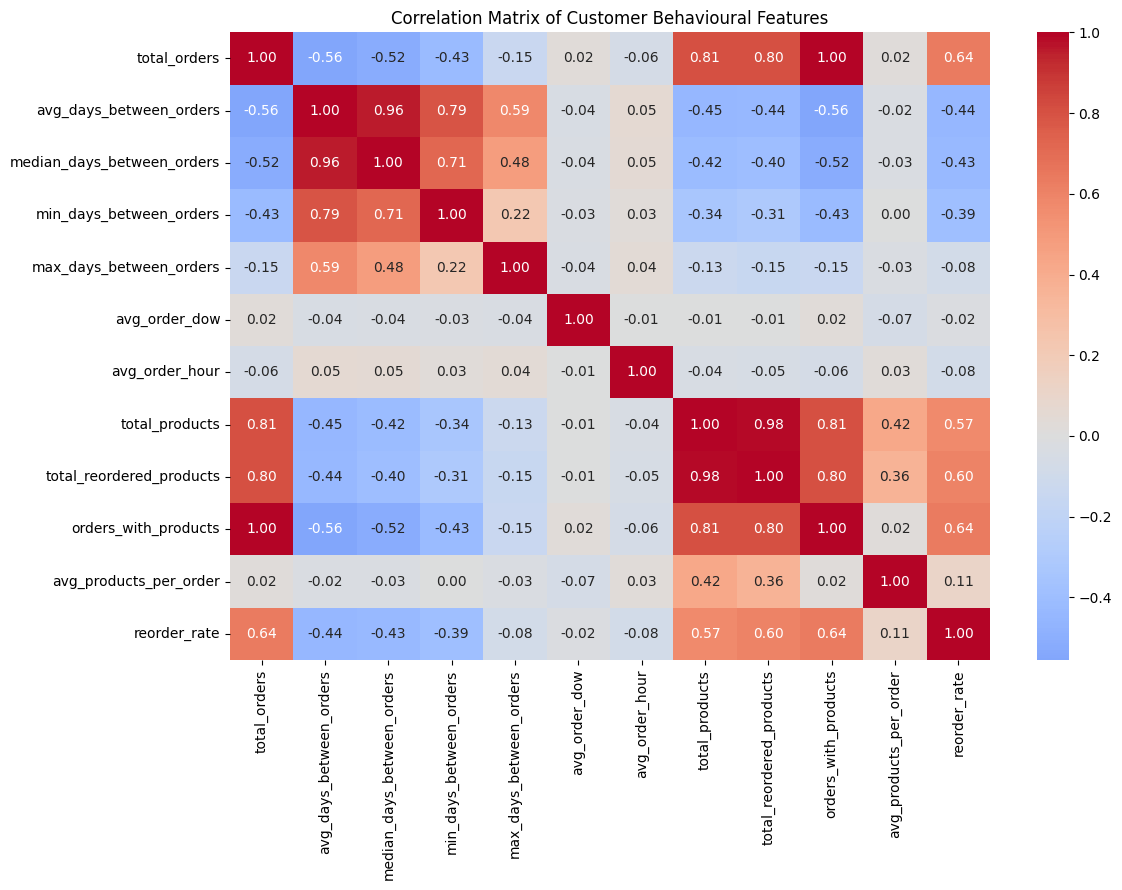

In [14]:
# ============================================================
# STEP 9: CORRELATION ANALYSIS
# ============================================================

# Select behavioural variables only
behaviour_features = customer_features.drop(
    columns=["user_id"]
).copy()

print("=" * 70)
print("BEHAVIOURAL FEATURE CORRELATION ANALYSIS")
print("=" * 70)

# Correlation matrix
correlation_matrix = behaviour_features.corr()

# Display correlation matrix
display(correlation_matrix.round(2))

# ------------------------------------------------------------
# Visualize correlations
# ------------------------------------------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Customer Behavioural Features")
plt.tight_layout()
plt.show()

## 9. Distribution and Outlier Analysis

Customer behavioural variables may have different distributions and may contain extreme observations.

Outlier analysis is therefore performed before clustering to understand the extent of skewness and extreme values.

Outliers will not automatically be removed. In a customer segmentation problem, unusually high-frequency or high-volume shoppers may represent genuine and commercially important customers rather than data errors.

The analysis will therefore distinguish between:

- Genuine behavioural extremes
- Potential data-quality problems

Where appropriate, transformations such as logarithmic scaling may be considered before standardization.

In [15]:
# ============================================================
# STEP 10: DISTRIBUTION AND OUTLIER ANALYSIS
# ============================================================

# Provisional behavioural features
provisional_features = [
    "total_orders",
    "avg_days_between_orders",
    "min_days_between_orders",
    "max_days_between_orders",
    "avg_order_dow",
    "avg_order_hour",
    "avg_products_per_order",
    "reorder_rate"
]

analysis_df = customer_features[provisional_features].copy()

# ------------------------------------------------------------
# Distribution statistics
# ------------------------------------------------------------

distribution_summary = pd.DataFrame({
    "Mean": analysis_df.mean(),
    "Median": analysis_df.median(),
    "Std_Dev": analysis_df.std(),
    "Min": analysis_df.min(),
    "Max": analysis_df.max(),
    "Skewness": analysis_df.skew()
})

print("=" * 80)
print("DISTRIBUTION SUMMARY")
print("=" * 80)

display(distribution_summary.round(3))

# ------------------------------------------------------------
# IQR-based outlier analysis
# ------------------------------------------------------------

outlier_summary = []

for column in provisional_features:

    Q1 = analysis_df[column].quantile(0.25)
    Q3 = analysis_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (analysis_df[column] < lower_bound) |
        (analysis_df[column] > upper_bound)
    )

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers.sum(),
        "Outlier_Percentage": outliers.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

print("\n" + "=" * 80)
print("IQR-BASED OUTLIER SUMMARY")
print("=" * 80)

display(outlier_summary.round(2))

DISTRIBUTION SUMMARY


,Mean,Median,Std_Dev,Min,Max,Skewness
total_orders,15.590,9.000,16.655,3.0,99.00,2.400
avg_days_between_orders,15.209,14.500,7.105,0.0,30.00,0.343
min_days_between_orders,6.472,4.000,7.579,0.0,30.00,1.787
max_days_between_orders,26.302,30.000,6.655,0.0,30.00,-1.692
avg_order_dow,2.753,2.750,0.941,0.0,6.00,0.028
avg_order_hour,13.586,13.571,2.110,0.0,23.00,-0.003
avg_products_per_order,9.951,8.933,5.863,1.0,70.25,1.230
reorder_rate,0.432,0.429,0.212,0.0,0.99,0.035



IQR-BASED OUTLIER SUMMARY


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,total_orders,5.00,19.00,14.00,-16.00,40.00,17017,8.25
1,avg_days_between_orders,9.42,20.29,10.87,-6.89,36.59,0,0.00
2,min_days_between_orders,1.00,8.00,7.00,-9.50,18.50,18766,9.10
3,max_days_between_orders,25.00,30.00,5.00,17.50,37.50,29509,14.31
4,avg_order_dow,2.20,3.33,1.13,0.50,5.03,5262,2.55
5,avg_order_hour,12.22,15.00,2.78,8.06,19.17,2600,1.26
6,avg_products_per_order,5.74,13.00,7.26,-5.15,23.89,5551,2.69
7,reorder_rate,0.27,0.60,0.33,-0.22,1.09,0,0.00


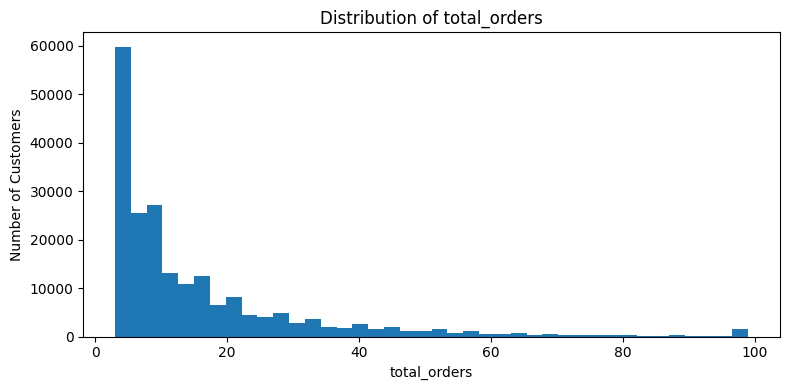

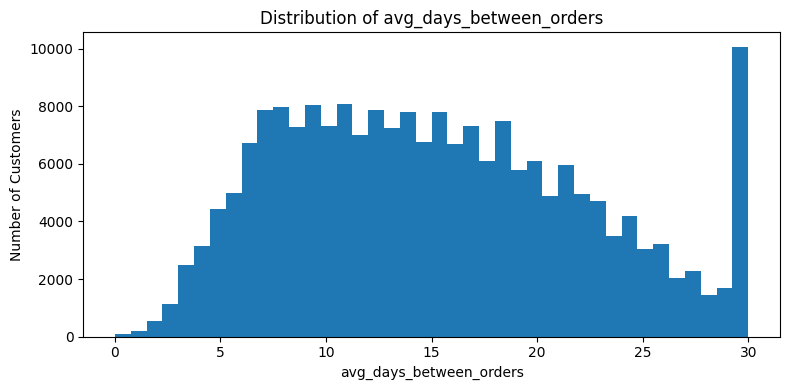

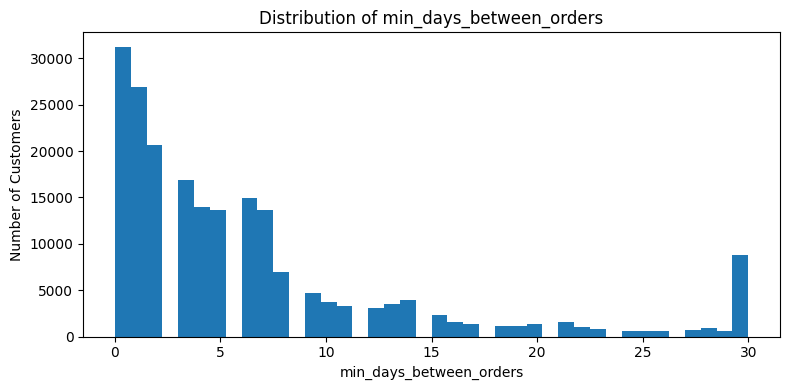

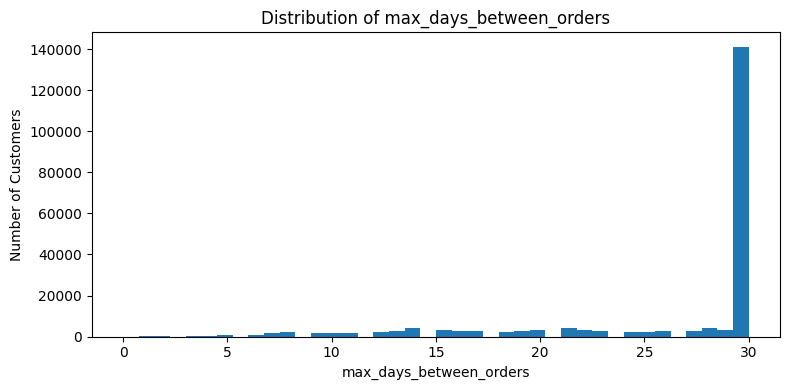

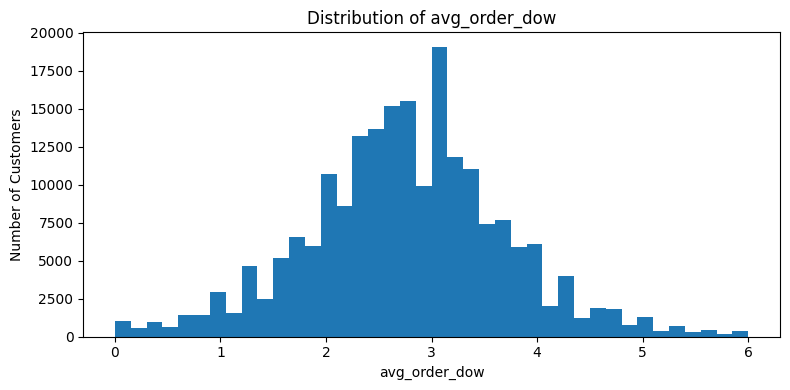

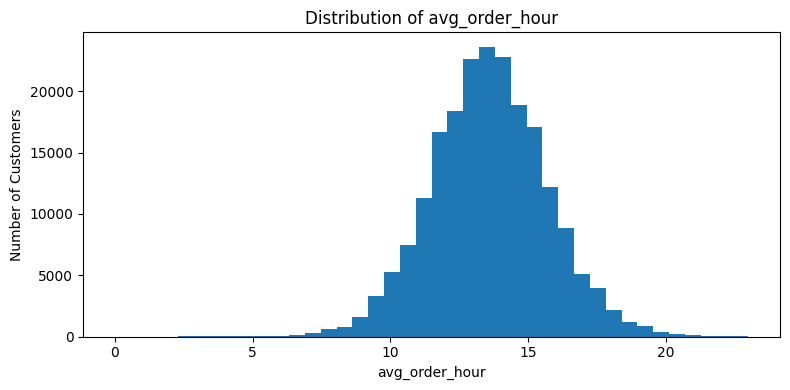

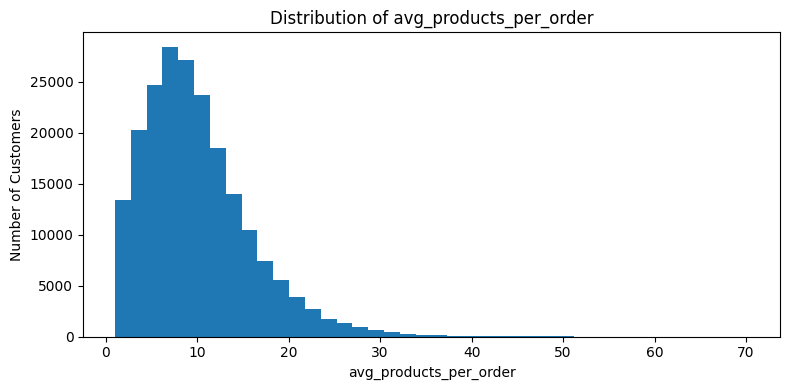

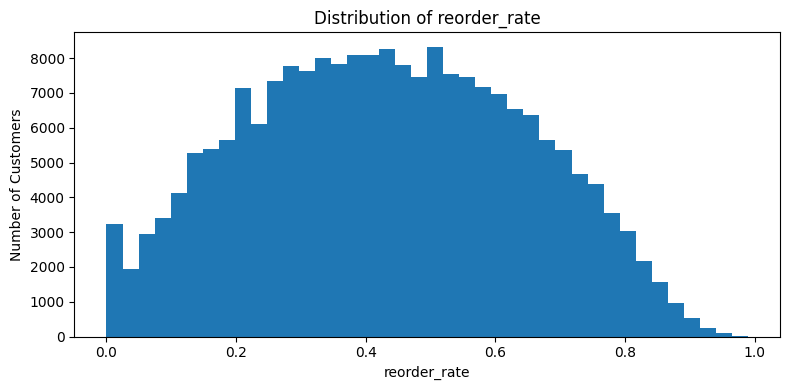

In [16]:
# ============================================================
# STEP 10B: VISUALIZE FEATURE DISTRIBUTIONS
# ============================================================

for column in provisional_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        analysis_df[column],
        bins=40
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

## 10. Feature Engineering for Shopper Segmentation

Based on the exploratory analysis, the initial clustering feature set is refined to reduce redundancy and improve behavioural representation.

Highly redundant variables are excluded based on the correlation analysis. In particular:

- `median_days_between_orders` is excluded because it is highly correlated with `avg_days_between_orders`.
- `total_reordered_products` is excluded because it is highly correlated with total product volume and reorder rate.
- `orders_with_products` is excluded because it is effectively equivalent to `total_orders` in the historical dataset.
- `max_days_between_orders` is excluded because the dataset records the previous-order interval only up to 30 days.

Additional behavioural measures are engineered:

- `weekend_order_share` captures the proportion of orders placed on weekends.
- `pct_30_day_gaps` captures the proportion of observed order gaps recorded at the 30-day upper bound.

The final clustering variables will be transformed and standardized where appropriate before model development.

In [17]:
# ============================================================
# STEP 11: CREATE IMPROVED BEHAVIOURAL FEATURES
# ============================================================

# ------------------------------------------------------------
# 1. Weekend order share
# ------------------------------------------------------------
# Instacart order_dow:
# 0 = Sunday
# 1 = Monday
# ...
# 6 = Saturday

orders_prior["is_weekend"] = orders_prior["order_dow"].isin([0, 6])

weekend_share = (
    orders_prior
    .groupby("user_id")["is_weekend"]
    .mean()
    .rename("weekend_order_share")
    .reset_index()
)

# ------------------------------------------------------------
# 2. Percentage of order gaps recorded at 30 days
# ------------------------------------------------------------

gap_30_share = (
    orders_prior
    .assign(
        is_30_day_gap=(
            orders_prior["days_since_prior_order"] == 30
        )
    )
    .groupby("user_id")["is_30_day_gap"]
    .mean()
    .rename("pct_30_day_gaps")
    .reset_index()
)

# ------------------------------------------------------------
# 3. Merge into customer feature dataset
# ------------------------------------------------------------

customer_features = customer_features.merge(
    weekend_share,
    on="user_id",
    how="left",
    validate="one_to_one"
)

customer_features = customer_features.merge(
    gap_30_share,
    on="user_id",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 4. Check the new features
# ------------------------------------------------------------

print("=" * 70)
print("NEW ENGINEERED FEATURES")
print("=" * 70)

print("\nShape:", customer_features.shape)

print("\nNew feature summary:")
display(
    customer_features[
        ["weekend_order_share", "pct_30_day_gaps"]
    ].describe().round(3)
)

print("\nFirst 10 customers:")
display(
    customer_features[
        [
            "user_id",
            "weekend_order_share",
            "pct_30_day_gaps"
        ]
    ].head(10)
)

print("\nMissing values:")
display(
    customer_features[
        ["weekend_order_share", "pct_30_day_gaps"]
    ].isnull().sum()
)

NEW ENGINEERED FEATURES

Shape: (206209, 15)

New feature summary:


,weekend_order_share,pct_30_day_gaps
count,206209.000,206209.000
mean,0.320,0.185
std,0.248,0.203
min,0.000,0.000
25%,0.133,0.000
50%,0.295,0.125
75%,0.500,0.333
max,1.000,0.889



First 10 customers:


,user_id,weekend_order_share,pct_30_day_gaps
0,1,0.000000,0.100000
1,2,0.000000,0.142857
2,3,0.500000,0.000000
3,4,0.200000,0.000000
4,5,0.250000,0.000000
5,6,0.000000,0.000000
6,7,0.350000,0.100000
7,8,0.333333,0.666667
8,9,0.333333,0.333333
9,10,0.000000,0.200000



Missing values:


,0
weekend_order_share,0
pct_30_day_gaps,0


## 11. Final Feature Selection for Clustering

Based on exploratory analysis, correlation analysis and business relevance, a reduced set of behavioural variables is selected for clustering.

The selected variables represent several dimensions of shopper behaviour:

- Purchase frequency
- Replenishment interval
- Basket size
- Reorder tendency
- Shopping time
- Weekend shopping preference
- Frequency of 30-day recorded order gaps

Highly redundant variables are excluded to avoid giving excessive weight to the same underlying behaviour.

The customer identifier is excluded from modelling because it is only an identifier.

The selected variables are:

1. `total_orders`
2. `avg_days_between_orders`
3. `avg_order_hour`
4. `avg_products_per_order`
5. `reorder_rate`
6. `weekend_order_share`
7. `pct_30_day_gaps`

In [18]:
# ============================================================
# STEP 12: CREATE FINAL CLUSTERING DATASET
# ============================================================

clustering_features = [
    "total_orders",
    "avg_days_between_orders",
    "avg_order_hour",
    "avg_products_per_order",
    "reorder_rate",
    "weekend_order_share",
    "pct_30_day_gaps"
]

X = customer_features[clustering_features].copy()

print("=" * 70)
print("FINAL CLUSTERING DATASET")
print("=" * 70)

print("\nShape:", X.shape)

print("\nSelected features:")
for i, feature in enumerate(clustering_features, 1):
    print(f"{i}. {feature}")

print("\nMissing values:")
display(X.isnull().sum())

print("\nSummary statistics:")
display(X.describe().round(3))

FINAL CLUSTERING DATASET

Shape: (206209, 7)

Selected features:
1. total_orders
2. avg_days_between_orders
3. avg_order_hour
4. avg_products_per_order
5. reorder_rate
6. weekend_order_share
7. pct_30_day_gaps

Missing values:


,0
total_orders,0
avg_days_between_orders,0
avg_order_hour,0
avg_products_per_order,0
reorder_rate,0
weekend_order_share,0
pct_30_day_gaps,0



Summary statistics:


,total_orders,avg_days_between_orders,avg_order_hour,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
count,206209.000,206209.000,206209.000,206209.000,206209.000,206209.000,206209.000
mean,15.590,15.209,13.586,9.951,0.432,0.320,0.185
std,16.655,7.105,2.110,5.863,0.212,0.248,0.203
min,3.000,0.000,0.000,1.000,0.000,0.000,0.000
25%,5.000,9.417,12.222,5.741,0.268,0.133,0.000
50%,9.000,14.500,13.571,8.933,0.429,0.295,0.125
75%,19.000,20.286,15.000,13.000,0.596,0.500,0.333
max,99.000,30.000,23.000,70.250,0.990,1.000,0.889


In [19]:
# ============================================================
# STEP 13: TRANSFORM SKEWED FEATURES
# ============================================================

X_transformed = X.copy()

# Log transformation for positively skewed variables
X_transformed["total_orders"] = np.log1p(
    X_transformed["total_orders"]
)

X_transformed["avg_products_per_order"] = np.log1p(
    X_transformed["avg_products_per_order"]
)

print("=" * 70)
print("TRANSFORMED FEATURE SUMMARY")
print("=" * 70)

display(
    X_transformed.describe().round(3)
)

print("\nSkewness after transformation:")
display(
    X_transformed.skew().round(3)
)

TRANSFORMED FEATURE SUMMARY


,total_orders,avg_days_between_orders,avg_order_hour,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
count,206209.000,206209.000,206209.000,206209.000,206209.000,206209.000,206209.000
mean,2.454,15.209,13.586,2.251,0.432,0.320,0.185
std,0.801,7.105,2.110,0.552,0.212,0.248,0.203
min,1.386,0.000,0.000,0.693,0.000,0.000,0.000
25%,1.792,9.417,12.222,1.908,0.268,0.133,0.000
50%,2.303,14.500,13.571,2.296,0.429,0.295,0.125
75%,2.996,20.286,15.000,2.639,0.596,0.500,0.333
max,4.605,30.000,23.000,4.266,0.990,1.000,0.889



Skewness after transformation:


,0
total_orders,0.556
avg_days_between_orders,0.343
avg_order_hour,-0.003
avg_products_per_order,-0.327
reorder_rate,0.035
weekend_order_share,0.614
pct_30_day_gaps,1.063


## 13. Project Sampling Strategy

The full Instacart dataset contains more than 200,000 users and several million orders. In accordance with the approved project proposal, approximately 50,000 users are selected for the main shopper segmentation analysis.

A fixed random seed is used to make the sampling reproducible.

Importantly, sampling is performed at the customer level rather than at the transaction-row level. Once a customer is selected, their available historical order records are retained. This avoids creating partial customer histories through random transaction sampling.

The full customer-level dataset remains available for reference, while the sampled customer population is used for the main segmentation analysis.

In [20]:
# ============================================================
# STEP 14: SELECT THE PROJECT SAMPLE
# ============================================================

RANDOM_STATE = 42
SAMPLE_SIZE = 50_000

# All customers available in our customer-level dataset
all_users = customer_features["user_id"].unique()

print("Total customers available:", len(all_users))

# Reproducible random sample
rng = np.random.default_rng(RANDOM_STATE)

sampled_users = rng.choice(
    all_users,
    size=SAMPLE_SIZE,
    replace=False
)

sampled_users = np.sort(sampled_users)

print("Sampled customers:", len(sampled_users))
print("Random state:", RANDOM_STATE)

# ------------------------------------------------------------
# Create a lookup set for efficient filtering later
# ------------------------------------------------------------

sampled_user_set = set(sampled_users)

# Customer-level features for sampled users
sampled_customer_features = (
    customer_features[
        customer_features["user_id"].isin(sampled_user_set)
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nSampled customer feature dataset shape:")
print(sampled_customer_features.shape)

print("\nFirst 10 sampled customers:")
display(sampled_customer_features.head(10))

print("\nSample validation:")
print(
    "Unique sampled user IDs:",
    sampled_customer_features["user_id"].nunique()
)

Total customers available: 206209
Sampled customers: 50000
Random state: 42

Sampled customer feature dataset shape:
(50000, 15)

First 10 sampled customers:


,user_id,total_orders,avg_days_between_orders,median_days_between_orders,min_days_between_orders,max_days_between_orders,avg_order_dow,avg_order_hour,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
0,1,10,19.555556,20.0,0.0,30.0,2.500000,10.300000,59,41,10,5.900000,0.694915,0.000000,0.100000
1,3,12,12.090909,11.0,7.0,21.0,1.083333,16.416667,88,55,12,7.333333,0.625000,0.500000,0.000000
2,4,5,13.750000,17.0,0.0,21.0,4.800000,12.600000,18,1,5,3.600000,0.055556,0.200000,0.000000
3,8,3,30.000000,30.0,30.0,30.0,4.000000,2.666667,49,13,3,16.333333,0.265306,0.333333,0.666667
4,9,3,18.000000,18.0,6.0,30.0,2.000000,14.333333,76,18,3,25.333333,0.236842,0.333333,0.333333
5,19,9,9.500000,7.5,5.0,20.0,4.444444,12.777778,204,71,9,22.666667,0.348039,0.333333,0.000000
6,23,4,14.666667,9.0,5.0,30.0,3.250000,11.750000,40,4,4,10.000000,0.100000,0.250000,0.250000
7,28,24,11.695652,11.0,1.0,30.0,1.875000,14.833333,183,77,24,7.625000,0.420765,0.291667,0.083333
8,31,20,4.894737,6.0,0.0,10.0,2.200000,11.700000,299,109,20,14.950000,0.364548,0.250000,0.000000
9,36,37,9.722222,8.5,0.0,25.0,3.000000,14.594595,153,98,37,4.135135,0.640523,0.351351,0.000000



Sample validation:
Unique sampled user IDs: 50000


## 14. Customer–Aisle Purchase Matrix

For the main segmentation analysis, customer purchasing behaviour is represented using an aisle-level purchase matrix.

Each row represents one sampled customer and each column represents one of the 134 grocery aisles.

The value in each cell represents the number of products purchased by that customer from the corresponding aisle across their historical prior orders.

This representation captures differences in product-category preferences while reducing the dimensionality of the original product-level transaction data.

The resulting 50,000 × 134 matrix will be used as the main input for Principal Component Analysis (PCA), followed by clustering.

In [21]:
# ============================================================
# STEP 15: BUILD CUSTOMER × AISLE PURCHASE MATRIX
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# 1. Create sampled customer index
# ------------------------------------------------------------

sampled_users_sorted = np.sort(sampled_users)

user_to_row = {
    user_id: idx
    for idx, user_id in enumerate(sampled_users_sorted)
}

# ------------------------------------------------------------
# 2. Get historical orders belonging to sampled customers
# ------------------------------------------------------------

sampled_orders = orders_prior[
    orders_prior["user_id"].isin(sampled_user_set)
][["order_id", "user_id"]].copy()

print("Sampled historical orders:", len(sampled_orders))
print("Sampled customers:", sampled_orders["user_id"].nunique())

# ------------------------------------------------------------
# 3. Create order_id → user_id lookup
# ------------------------------------------------------------

order_to_user = sampled_orders.set_index("order_id")["user_id"]

# ------------------------------------------------------------
# 4. Create aisle mapping
# ------------------------------------------------------------

aisle_ids = np.sort(aisles["aisle_id"].unique())

aisle_to_col = {
    aisle_id: idx
    for idx, aisle_id in enumerate(aisle_ids)
}

print("Number of aisles:", len(aisle_ids))

# ------------------------------------------------------------
# 5. Initialize purchase matrix
# ------------------------------------------------------------
# Rows    = 50,000 customers
# Columns = 134 aisles

aisle_purchase_matrix = np.zeros(
    (len(sampled_users_sorted), len(aisle_ids)),
    dtype=np.int32
)

# ------------------------------------------------------------
# 6. Process the large prior-order file in chunks
# ------------------------------------------------------------

CHUNK_SIZE = 500_000
prior_file = "order_products__prior.csv"

total_rows_processed = 0
total_sampled_rows = 0
chunk_number = 0

for chunk in pd.read_csv(
    prior_file,
    chunksize=CHUNK_SIZE,
    usecols=["order_id", "product_id"],
    dtype={
        "order_id": "int32",
        "product_id": "int32"
    }
):

    chunk_number += 1
    total_rows_processed += len(chunk)

    # --------------------------------------------------------
    # Keep only transactions belonging to sampled customers
    # --------------------------------------------------------

    chunk = chunk.merge(
        sampled_orders,
        on="order_id",
        how="inner"
    )

    if len(chunk) == 0:
        print(
            f"Chunk {chunk_number}: "
            f"no sampled transactions"
        )
        continue

    total_sampled_rows += len(chunk)

    # --------------------------------------------------------
    # Add aisle information
    # --------------------------------------------------------

    chunk = chunk.merge(
        products[["product_id", "aisle_id"]],
        on="product_id",
        how="left"
    )

    # --------------------------------------------------------
    # Aggregate purchases by customer and aisle
    # --------------------------------------------------------

    grouped = (
        chunk
        .groupby(
            ["user_id", "aisle_id"],
            sort=False
        )
        .size()
        .reset_index(name="purchase_count")
    )

    # --------------------------------------------------------
    # Convert IDs to matrix positions
    # --------------------------------------------------------

    row_indices = grouped["user_id"].map(user_to_row).to_numpy()
    col_indices = grouped["aisle_id"].map(aisle_to_col).to_numpy()
    values = grouped["purchase_count"].to_numpy(
        dtype=np.int32
    )

    # Add counts to matrix
    aisle_purchase_matrix[
        row_indices,
        col_indices
    ] += values

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    print(
        f"Chunk {chunk_number:02d} | "
        f"Total rows scanned: {total_rows_processed:,} | "
        f"Sampled transaction rows: {total_sampled_rows:,}"
    )

print("\n" + "=" * 70)
print("AISLE MATRIX CREATION COMPLETED")
print("=" * 70)

print("Matrix shape:", aisle_purchase_matrix.shape)
print("Total purchase observations:", aisle_purchase_matrix.sum())
print("Non-zero cells:", np.count_nonzero(aisle_purchase_matrix))

print(
    "Matrix density:",
    round(
        np.count_nonzero(aisle_purchase_matrix)
        / aisle_purchase_matrix.size * 100,
        2
    ),
    "%"
)

Sampled historical orders: 773963
Sampled customers: 50000
Number of aisles: 134
Chunk 01 | Total rows scanned: 500,000 | Sampled transaction rows: 120,902
Chunk 02 | Total rows scanned: 1,000,000 | Sampled transaction rows: 241,366
Chunk 03 | Total rows scanned: 1,500,000 | Sampled transaction rows: 361,606
Chunk 04 | Total rows scanned: 2,000,000 | Sampled transaction rows: 483,654
Chunk 05 | Total rows scanned: 2,500,000 | Sampled transaction rows: 602,292
Chunk 06 | Total rows scanned: 3,000,000 | Sampled transaction rows: 721,607
Chunk 07 | Total rows scanned: 3,500,000 | Sampled transaction rows: 843,850
Chunk 08 | Total rows scanned: 4,000,000 | Sampled transaction rows: 964,984
Chunk 09 | Total rows scanned: 4,500,000 | Sampled transaction rows: 1,086,728
Chunk 10 | Total rows scanned: 5,000,000 | Sampled transaction rows: 1,207,703
Chunk 11 | Total rows scanned: 5,500,000 | Sampled transaction rows: 1,327,427
Chunk 12 | Total rows scanned: 6,000,000 | Sampled transaction rows:

## 15. Normalizing the Customer–Aisle Purchase Matrix

The raw customer–aisle matrix contains purchase counts. However, customers differ substantially in their overall purchasing volume.

To focus the PCA on differences in **aisle purchasing preferences**, rather than simply total shopping volume, each customer's aisle counts are converted into proportions of their total purchases.

Thus, each customer's row represents their purchasing mix across the 134 aisles.

Overall purchase volume and reorder behaviour are retained separately for subsequent cluster profiling and business validation.

In [22]:
# ============================================================
# STEP 16: CONVERT AISLE COUNTS TO CUSTOMER PURCHASE SHARES
# ============================================================

# Total purchases made by each sampled customer
customer_total_purchases = aisle_purchase_matrix.sum(axis=1)

print("Customers with zero purchases:",
      np.sum(customer_total_purchases == 0))

print("Minimum purchases by a sampled customer:",
      customer_total_purchases.min())

print("Maximum purchases by a sampled customer:",
      customer_total_purchases.max())

# ------------------------------------------------------------
# Convert counts into proportions
# ------------------------------------------------------------

aisle_purchase_share = (
    aisle_purchase_matrix.astype(np.float32)
    / customer_total_purchases[:, np.newaxis]
)

print("\nPurchase-share matrix shape:")
print(aisle_purchase_share.shape)

print("\nRow-sum check:")
row_sums = aisle_purchase_share.sum(axis=1)

print("Minimum row sum:", row_sums.min())
print("Maximum row sum:", row_sums.max())

# ------------------------------------------------------------
# Display first few rows
# ------------------------------------------------------------

print("\nFirst 5 customers × first 10 aisles:")
display(
    pd.DataFrame(
        aisle_purchase_share[:5, :10]
    ).round(4)
)

Customers with zero purchases: 0
Minimum purchases by a sampled customer: 3
Maximum purchases by a sampled customer: 3061

Purchase-share matrix shape:
(50000, 134)

Row-sum check:
Minimum row sum: 0.9999999999999997
Maximum row sum: 1.0000000000000004

First 5 customers × first 10 aisles:


,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0000,0.0455,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0132,0.0000,0.0,0.0,0.0,0.0,0.0,0.0


## 16. Standardization Before PCA

The customer–aisle purchase-share matrix contains 134 variables representing different aisles.

Before applying PCA, the variables are standardized so that differences in numerical scale do not cause particular aisles to dominate the dimensionality-reduction process.

The standardized aisle-level purchase preferences are then used as the input to PCA.

In [23]:
# ============================================================
# STEP 17: STANDARDIZE AISLE PURCHASE SHARES
# ============================================================

from sklearn.preprocessing import StandardScaler

# Standardize the 134 aisle-share variables
aisle_scaler = StandardScaler()

aisle_share_scaled = aisle_scaler.fit_transform(
    aisle_purchase_share
)

print("=" * 70)
print("STANDARDIZED AISLE MATRIX")
print("=" * 70)

print("\nOriginal shape:")
print(aisle_purchase_share.shape)

print("\nStandardized shape:")
print(aisle_share_scaled.shape)

# ------------------------------------------------------------
# Check means and standard deviations
# ------------------------------------------------------------

print("\nFirst 10 standardized feature means:")
print(
    np.round(
        aisle_share_scaled.mean(axis=0)[:10],
        6
    )
)

print("\nFirst 10 standardized feature standard deviations:")
print(
    np.round(
        aisle_share_scaled.std(axis=0)[:10],
        6
    )
)

# ------------------------------------------------------------
# Overall sanity check
# ------------------------------------------------------------

print("\nOverall mean:")
print(round(aisle_share_scaled.mean(), 6))

print("\nOverall standard deviation:")
print(round(aisle_share_scaled.std(), 6))

STANDARDIZED AISLE MATRIX

Original shape:
(50000, 134)

Standardized shape:
(50000, 134)

First 10 standardized feature means:
[-0. -0.  0. -0. -0.  0.  0.  0.  0.  0.]

First 10 standardized feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Overall mean:
0.0

Overall standard deviation:
1.0


## 17. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to the standardized 134-aisle customer purchase-share matrix to reduce dimensionality.

PCA transforms the original aisle-level variables into a smaller set of orthogonal principal components that capture the major sources of variation in shopper purchasing preferences.

All 134 components are initially calculated so that the explained variance and cumulative explained variance can be examined before selecting the number of components for clustering.

The number of retained components will be selected using cumulative explained variance together with interpretability and clustering performance.

PCA RESULTS

Original number of features: 134
Number of PCA components: 134

First 10 components:


,Component,Explained_Variance,Cumulative_Variance
0,1,0.0251,0.0251
1,2,0.0189,0.0440
2,3,0.0167,0.0607
3,4,0.0136,0.0744
4,5,0.0125,0.0868
5,6,0.0123,0.0992
6,7,0.0113,0.1104
7,8,0.0106,0.1210
8,9,0.0104,0.1315
9,10,0.0102,0.1417



Components required for cumulative explained variance:
70% variance: 84 components
80% variance: 99 components
90% variance: 115 components
95% variance: 124 components


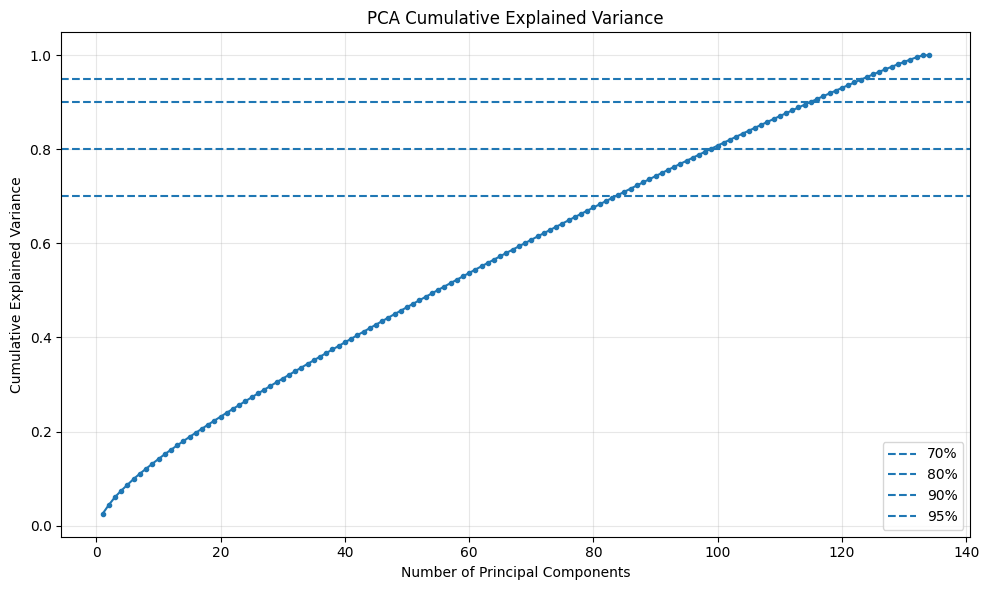

In [24]:
# ============================================================
# STEP 18: PCA WITH ALL COMPONENTS
# ============================================================

from sklearn.decomposition import PCA

# Fit PCA with all 134 components
pca_full = PCA(n_components=134, random_state=42)

X_pca_full = pca_full.fit_transform(aisle_share_scaled)

# ------------------------------------------------------------
# Explained variance
# ------------------------------------------------------------

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

print("=" * 70)
print("PCA RESULTS")
print("=" * 70)

print("\nOriginal number of features:", aisle_share_scaled.shape[1])
print("Number of PCA components:", X_pca_full.shape[1])

print("\nFirst 10 components:")
display(
    pca_summary.head(10).round(4)
)

# ------------------------------------------------------------
# Variance thresholds
# ------------------------------------------------------------

thresholds = [0.70, 0.80, 0.90, 0.95]

print("\nComponents required for cumulative explained variance:")

for threshold in thresholds:
    n_components = np.argmax(
        cumulative_variance >= threshold
    ) + 1

    print(
        f"{threshold*100:.0f}% variance: "
        f"{n_components} components"
    )

# ------------------------------------------------------------
# Plot cumulative explained variance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=3
)

plt.axhline(
    y=0.70,
    linestyle="--",
    label="70%"
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80%"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90%"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95%"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. PCA Representation Sensitivity Check

The initial PCA on standardized aisle purchase shares produced a relatively diffuse variance structure, with many components required to explain a large proportion of total variance.

Because customer purchase counts are highly skewed, an alternative representation is evaluated using a `log1p` transformation of aisle purchase counts before PCA.

This sensitivity check helps determine whether the dimensionality-reduction result is robust to the representation of purchasing behaviour.

The final representation will be selected based on explained variance, dimensionality reduction and subsequent clustering performance rather than choosing a representation arbitrarily.

Log-transformed matrix shape:
(50000, 134)

Minimum value: 0.0
Maximum value: 6.764

Standardized log-count matrix shape:
(50000, 134)

LOG-COUNT PCA RESULTS

First 10 components:


,Component,Explained_Variance,Cumulative_Variance
0,1,0.1520,0.1520
1,2,0.0405,0.1925
2,3,0.0226,0.2151
3,4,0.0211,0.2362
4,5,0.0191,0.2553
5,6,0.0143,0.2696
6,7,0.0134,0.2830
7,8,0.0120,0.2950
8,9,0.0113,0.3063
9,10,0.0105,0.3168



Components required for cumulative explained variance:
50% variance: 34 components
60% variance: 49 components
70% variance: 66 components
80% variance: 85 components
90% variance: 106 components
95% variance: 119 components


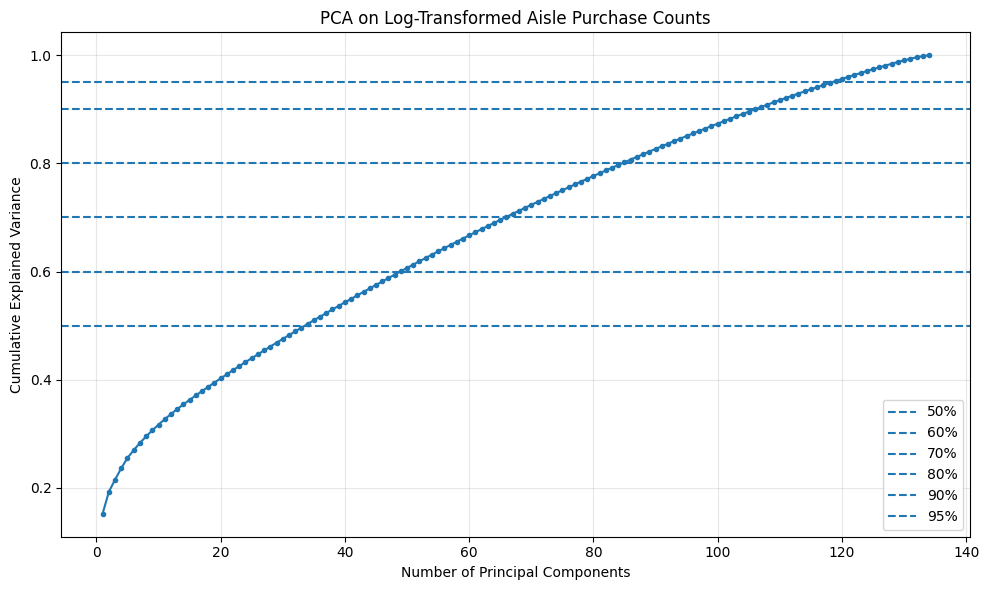

In [25]:
# ============================================================
# STEP 18B: PCA SENSITIVITY CHECK USING LOG-TRANSFORMED COUNTS
# ============================================================

# Log-transform the raw aisle purchase counts
aisle_counts_log = np.log1p(
    aisle_purchase_matrix.astype(np.float32)
)

print("Log-transformed matrix shape:")
print(aisle_counts_log.shape)

print("\nMinimum value:", aisle_counts_log.min())
print("Maximum value:", round(aisle_counts_log.max(), 3))

# ------------------------------------------------------------
# Standardize the log-transformed counts
# ------------------------------------------------------------

count_scaler = StandardScaler()

aisle_counts_log_scaled = count_scaler.fit_transform(
    aisle_counts_log
)

print("\nStandardized log-count matrix shape:")
print(aisle_counts_log_scaled.shape)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca_log = PCA(
    n_components=134,
    random_state=42
)

X_pca_log = pca_log.fit_transform(
    aisle_counts_log_scaled
)

explained_log = pca_log.explained_variance_ratio_
cumulative_log = np.cumsum(explained_log)

pca_log_summary = pd.DataFrame({
    "Component": np.arange(1, 135),
    "Explained_Variance": explained_log,
    "Cumulative_Variance": cumulative_log
})

print("\n" + "=" * 70)
print("LOG-COUNT PCA RESULTS")
print("=" * 70)

print("\nFirst 10 components:")
display(
    pca_log_summary.head(10).round(4)
)

print("\nComponents required for cumulative explained variance:")

for threshold in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:

    n_components = np.argmax(
        cumulative_log >= threshold
    ) + 1

    print(
        f"{threshold*100:.0f}% variance: "
        f"{n_components} components"
    )

# ------------------------------------------------------------
# Cumulative explained variance plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 135),
    cumulative_log,
    marker="o",
    markersize=3
)

for threshold in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    plt.axhline(
        y=threshold,
        linestyle="--",
        label=f"{threshold*100:.0f}%"
    )

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA on Log-Transformed Aisle Purchase Counts")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Selecting the PCA Representation

The PCA results show that shopper purchasing behaviour is distributed across multiple dimensions rather than being captured by only a few principal components.

Instead of selecting the number of components solely from an arbitrary variance threshold, several compact PCA representations are evaluated.

Candidate dimensions are examined to balance:

- Dimensionality reduction
- Information retained
- Computational efficiency
- Suitability for subsequent clustering

The final number of components will be selected after considering both explained variance and clustering quality.

PCA DIMENSION COMPARISON


,Components,Explained_Variance_%,Variance_Lost_%,Reduction_from_134_%
0,10,31.680000,68.320000,92.54
1,15,36.270000,63.730000,88.81
2,20,40.240002,59.759998,85.07
3,25,43.980000,56.020000,81.34
4,30,47.540001,52.459999,77.61
5,40,54.310001,45.689999,70.15
6,50,60.669998,39.330002,62.69


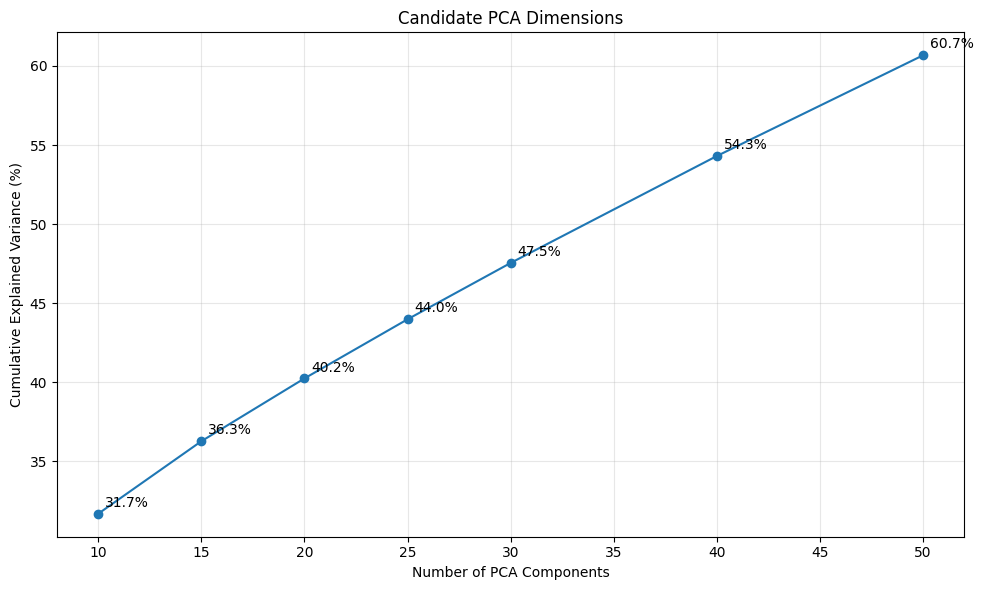

In [26]:
# ============================================================
# STEP 19: COMPARE CANDIDATE PCA DIMENSIONS
# ============================================================

candidate_components = [10, 15, 20, 25, 30, 40, 50]

pca_dimension_summary = []

for n in candidate_components:

    explained = cumulative_log[n - 1]

    pca_dimension_summary.append({
        "Components": n,
        "Explained_Variance_%": explained * 100,
        "Variance_Lost_%": (1 - explained) * 100,
        "Reduction_from_134_%": (1 - n / 134) * 100
    })

pca_dimension_summary = pd.DataFrame(
    pca_dimension_summary
)

print("=" * 80)
print("PCA DIMENSION COMPARISON")
print("=" * 80)

display(
    pca_dimension_summary.round(2)
)

# ------------------------------------------------------------
# Plot explained variance against candidate dimensions
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    pca_dimension_summary["Components"],
    pca_dimension_summary["Explained_Variance_%"],
    marker="o"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Candidate PCA Dimensions")
plt.grid(True, alpha=0.3)

for _, row in pca_dimension_summary.iterrows():
    plt.annotate(
        f"{row['Explained_Variance_%']:.1f}%",
        (
            row["Components"],
            row["Explained_Variance_%"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## 20. Joint Evaluation of PCA Dimensions and Number of Clusters

The cumulative explained variance did not show a sharp elbow, indicating that shopper purchasing behaviour is distributed across many dimensions.

Therefore, PCA dimensionality and the number of clusters are evaluated jointly.

Candidate PCA representations of 10, 20, 30 and 40 components are compared using K-Means with 4, 5 and 6 clusters.

The evaluation uses:

- Within-cluster sum of squares (inertia)
- Silhouette score
- Cluster size distribution

Because silhouette calculation can be computationally expensive for 50,000 observations, a fixed random sample of 10,000 customers is used for silhouette evaluation. K-Means itself is fitted using the complete 50,000-customer sample.

The objective is to identify a PCA representation and cluster count that provide a good balance between dimensionality reduction, cluster separation and business usefulness.

In [27]:
# ============================================================
# STEP 20: EVALUATE PCA DIMENSIONS AND K-MEANS CLUSTERS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# Candidate PCA dimensions and cluster counts
# ------------------------------------------------------------

candidate_pca_dimensions = [10, 20, 30, 40]
candidate_k_values = [4, 5, 6]

# Fixed random seed for reproducibility
RANDOM_STATE = 42

# ------------------------------------------------------------
# Silhouette evaluation sample
# ------------------------------------------------------------

SILHOUETTE_SAMPLE_SIZE = 10_000

rng = np.random.default_rng(RANDOM_STATE)

silhouette_indices = rng.choice(
    len(X_pca_log),
    size=SILHOUETTE_SAMPLE_SIZE,
    replace=False
)

print("=" * 80)
print("K-MEANS VALIDATION ACROSS PCA DIMENSIONS")
print("=" * 80)

print("\nPCA dimensions tested:", candidate_pca_dimensions)
print("Cluster counts tested:", candidate_k_values)
print("Silhouette sample size:", SILHOUETTE_SAMPLE_SIZE)

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

kmeans_results = []

# ------------------------------------------------------------
# Evaluate each PCA dimension
# ------------------------------------------------------------

for n_components in candidate_pca_dimensions:

    print(
        f"\n{'-' * 70}\n"
        f"Evaluating PCA with {n_components} components"
        f"\n{'-' * 70}"
    )

    X_candidate = X_pca_log[:, :n_components]

    # Sample used only for silhouette calculation
    X_silhouette = X_candidate[silhouette_indices]

    for k in candidate_k_values:

        print(f"Running K-Means: k={k}")

        kmeans = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            max_iter=300,
            random_state=RANDOM_STATE
        )

        labels = kmeans.fit_predict(X_candidate)

        # ----------------------------------------------------
        # Inertia
        # ----------------------------------------------------

        inertia = kmeans.inertia_

        # ----------------------------------------------------
        # Silhouette score on fixed 10,000-customer sample
        # ----------------------------------------------------

        silhouette = silhouette_score(
            X_silhouette,
            labels[silhouette_indices],
            metric="euclidean"
        )

        # ----------------------------------------------------
        # Cluster sizes
        # ----------------------------------------------------

        cluster_counts = np.bincount(labels)

        smallest_cluster_pct = (
            cluster_counts.min()
            / len(labels)
            * 100
        )

        largest_cluster_pct = (
            cluster_counts.max()
            / len(labels)
            * 100
        )

        kmeans_results.append({
            "PCA_Components": n_components,
            "K": k,
            "Inertia": inertia,
            "Silhouette_Score": silhouette,
            "Smallest_Cluster_%": smallest_cluster_pct,
            "Largest_Cluster_%": largest_cluster_pct
        })

        print(
            f"  Inertia: {inertia:,.2f} | "
            f"Silhouette: {silhouette:.4f} | "
            f"Smallest cluster: {smallest_cluster_pct:.2f}% | "
            f"Largest cluster: {largest_cluster_pct:.2f}%"
        )

# ------------------------------------------------------------
# Results dataframe
# ------------------------------------------------------------

kmeans_results_df = pd.DataFrame(kmeans_results)

print("\n" + "=" * 80)
print("K-MEANS VALIDATION RESULTS")
print("=" * 80)

display(
    kmeans_results_df.round(4)
)

# ------------------------------------------------------------
# Rank by silhouette score
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TOP CONFIGURATIONS BY SILHOUETTE SCORE")
print("=" * 80)

display(
    kmeans_results_df
    .sort_values(
        "Silhouette_Score",
        ascending=False
    )
    .head(10)
    .round(4)
)

K-MEANS VALIDATION ACROSS PCA DIMENSIONS

PCA dimensions tested: [10, 20, 30, 40]
Cluster counts tested: [4, 5, 6]
Silhouette sample size: 10000

----------------------------------------------------------------------
Evaluating PCA with 10 components
----------------------------------------------------------------------
Running K-Means: k=4
  Inertia: 1,166,872.50 | Silhouette: 0.2752 | Smallest cluster: 5.24% | Largest cluster: 57.17%
Running K-Means: k=5
  Inertia: 1,094,997.00 | Silhouette: 0.2810 | Smallest cluster: 2.02% | Largest cluster: 55.88%
Running K-Means: k=6
  Inertia: 1,029,502.88 | Silhouette: 0.2130 | Smallest cluster: 1.96% | Largest cluster: 45.97%

----------------------------------------------------------------------
Evaluating PCA with 20 components
----------------------------------------------------------------------
Running K-Means: k=4
  Inertia: 1,738,214.12 | Silhouette: 0.2222 | Smallest cluster: 5.04% | Largest cluster: 56.85%
Running K-Means: k=5
  Inerti

,PCA_Components,K,Inertia,Silhouette_Score,Smallest_Cluster_%,Largest_Cluster_%
0,10,4,1166872.500,0.2752,5.236,57.166
1,10,5,1094997.000,0.2810,2.022,55.878
2,10,6,1029502.875,0.2130,1.964,45.968
3,20,4,1738214.125,0.2222,5.040,56.848
4,20,5,1666090.750,0.2289,2.014,56.066
5,20,6,1599897.000,0.1540,1.974,45.318
6,30,4,2226509.000,0.1995,5.014,56.672
7,30,5,2154268.250,0.2101,2.020,56.718
8,30,6,2087707.375,0.1329,1.958,45.794
9,40,4,2679191.750,0.1844,5.004,56.688



TOP CONFIGURATIONS BY SILHOUETTE SCORE


,PCA_Components,K,Inertia,Silhouette_Score,Smallest_Cluster_%,Largest_Cluster_%
1,10,5,1094997.000,0.2810,2.022,55.878
0,10,4,1166872.500,0.2752,5.236,57.166
4,20,5,1666090.750,0.2289,2.014,56.066
3,20,4,1738214.125,0.2222,5.040,56.848
2,10,6,1029502.875,0.2130,1.964,45.968
7,30,5,2154268.250,0.2101,2.020,56.718
6,30,4,2226509.000,0.1995,5.014,56.672
10,40,5,2606843.000,0.1933,2.006,56.588
9,40,4,2679191.750,0.1844,5.004,56.688
5,20,6,1599897.000,0.1540,1.974,45.318


## 21. Selecting the Number of Clusters

The previous evaluation identified 10 PCA components as the strongest candidate representation based on silhouette performance.

The number of clusters is now evaluated using the 10-component PCA representation.

K-Means models with K values from 2 to 8 are compared using:

- Within-Cluster Sum of Squares (WCSS / inertia)
- Silhouette Score
- Cluster-size distribution

The Elbow Method is used to identify diminishing returns from increasing the number of clusters, while the Silhouette Score measures the separation and cohesion of the resulting clusters.

The final number of clusters will consider both statistical validation and business interpretability.

ELBOW AND SILHOUETTE ANALYSIS — 10 PCA COMPONENTS

Running K-Means with K=2...
  Inertia: 1,438,107.75 | Silhouette: 0.4441 | Smallest cluster: 23.30% | Largest cluster: 76.70%

Running K-Means with K=3...
  Inertia: 1,267,802.25 | Silhouette: 0.2933 | Smallest cluster: 9.77% | Largest cluster: 59.77%

Running K-Means with K=4...
  Inertia: 1,166,872.50 | Silhouette: 0.2752 | Smallest cluster: 5.24% | Largest cluster: 57.17%

Running K-Means with K=5...
  Inertia: 1,094,997.00 | Silhouette: 0.2810 | Smallest cluster: 2.02% | Largest cluster: 55.88%

Running K-Means with K=6...
  Inertia: 1,029,502.88 | Silhouette: 0.2130 | Smallest cluster: 1.96% | Largest cluster: 45.97%

Running K-Means with K=7...
  Inertia: 985,266.88 | Silhouette: 0.1906 | Smallest cluster: 1.94% | Largest cluster: 42.25%

Running K-Means with K=8...
  Inertia: 946,661.62 | Silhouette: 0.1892 | Smallest cluster: 1.94% | Largest cluster: 41.30%

CLUSTER VALIDATION RESULTS


,K,Inertia,Silhouette_Score,Smallest_Cluster_%,Largest_Cluster_%
0,2,1438107.750,0.4441,23.302,76.698
1,3,1267802.250,0.2933,9.772,59.768
2,4,1166872.500,0.2752,5.236,57.166
3,5,1094997.000,0.2810,2.022,55.878
4,6,1029502.875,0.2130,1.964,45.968
5,7,985266.875,0.1906,1.942,42.248
6,8,946661.625,0.1892,1.938,41.304



BEST SILHOUETTE RESULT
K = 2
Silhouette Score = 0.4441


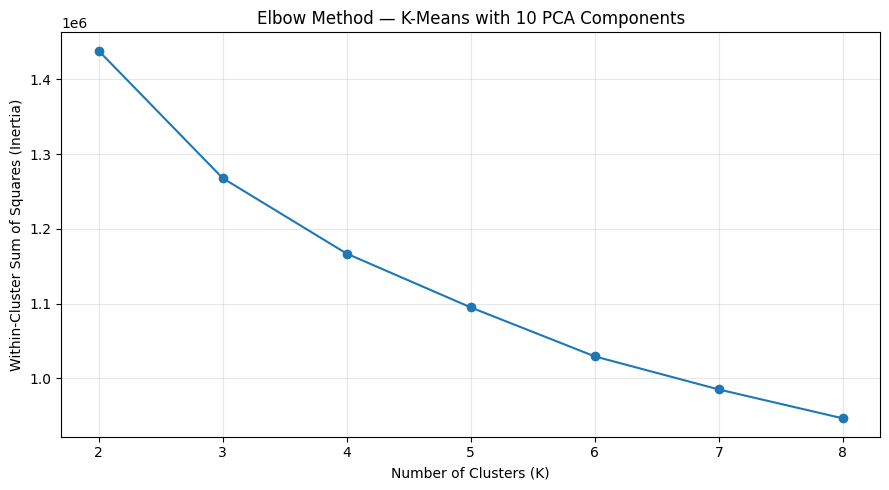

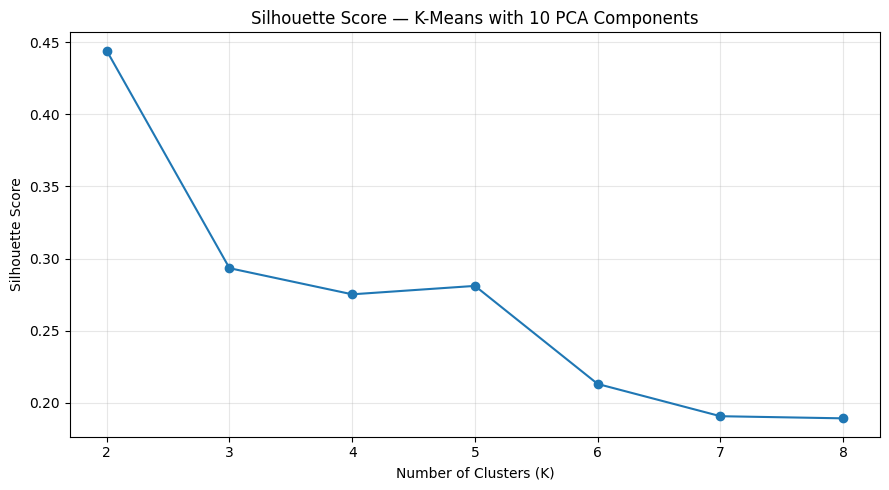

In [28]:
# ============================================================
# STEP 21: ELBOW + SILHOUETTE ANALYSIS
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# Use the selected 10-component PCA representation
# ------------------------------------------------------------

N_PCA_FINAL_CANDIDATE = 10

X_clustering = X_pca_log[:, :N_PCA_FINAL_CANDIDATE]

# ------------------------------------------------------------
# K values to evaluate
# ------------------------------------------------------------

k_range = range(2, 9)

# Use the same reproducible silhouette sample
SILHOUETTE_SAMPLE_SIZE = 10_000

rng = np.random.default_rng(42)

silhouette_indices_final = rng.choice(
    len(X_clustering),
    size=SILHOUETTE_SAMPLE_SIZE,
    replace=False
)

X_silhouette_final = X_clustering[
    silhouette_indices_final
]

# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

elbow_results = []

print("=" * 80)
print("ELBOW AND SILHOUETTE ANALYSIS — 10 PCA COMPONENTS")
print("=" * 80)

for k in k_range:

    print(f"\nRunning K-Means with K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    labels = kmeans.fit_predict(X_clustering)

    inertia = kmeans.inertia_

    silhouette = silhouette_score(
        X_silhouette_final,
        labels[silhouette_indices_final],
        metric="euclidean"
    )

    cluster_counts = np.bincount(labels)

    smallest_cluster_pct = (
        cluster_counts.min()
        / len(labels)
        * 100
    )

    largest_cluster_pct = (
        cluster_counts.max()
        / len(labels)
        * 100
    )

    elbow_results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette_Score": silhouette,
        "Smallest_Cluster_%": smallest_cluster_pct,
        "Largest_Cluster_%": largest_cluster_pct
    })

    print(
        f"  Inertia: {inertia:,.2f} | "
        f"Silhouette: {silhouette:.4f} | "
        f"Smallest cluster: {smallest_cluster_pct:.2f}% | "
        f"Largest cluster: {largest_cluster_pct:.2f}%"
    )

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

elbow_results_df = pd.DataFrame(elbow_results)

print("\n" + "=" * 80)
print("CLUSTER VALIDATION RESULTS")
print("=" * 80)

display(
    elbow_results_df.round(4)
)

# ------------------------------------------------------------
# Best silhouette
# ------------------------------------------------------------

best_silhouette_row = elbow_results_df.loc[
    elbow_results_df["Silhouette_Score"].idxmax()
]

print("\n" + "=" * 80)
print("BEST SILHOUETTE RESULT")
print("=" * 80)

print(
    f"K = {int(best_silhouette_row['K'])}"
)

print(
    f"Silhouette Score = "
    f"{best_silhouette_row['Silhouette_Score']:.4f}"
)

# ------------------------------------------------------------
# Elbow plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    elbow_results_df["K"],
    elbow_results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method — K-Means with 10 PCA Components")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Silhouette plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    elbow_results_df["K"],
    elbow_results_df["Silhouette_Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — K-Means with 10 PCA Components")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 22. Final K-Means Shopper Segmentation

Based on the combined Elbow Method, Silhouette Score and cluster-size analysis, a four-cluster K-Means solution is selected as the provisional final segmentation.

Although K=2 produced the highest Silhouette Score, it does not provide the desired level of shopper differentiation specified in the project design. K=4 provides a more practical segmentation with a substantially better minimum cluster size than K=5, while maintaining a comparable Silhouette Score.

The final K-Means model is fitted using:

- 50,000 sampled customers
- 10 PCA components
- K = 4 clusters
- K-Means++ initialization
- Fixed random state for reproducibility

The resulting cluster labels are then joined with customer-level behavioural features for business interpretation.

In [29]:
# ============================================================
# STEP 22: FIT FINAL PROVISIONAL K-MEANS MODEL
# ============================================================

FINAL_PCA_COMPONENTS = 10
FINAL_K = 4
RANDOM_STATE = 42

# ------------------------------------------------------------
# Final clustering input
# ------------------------------------------------------------

X_final = X_pca_log[:, :FINAL_PCA_COMPONENTS]

print("=" * 80)
print("FINAL PROVISIONAL K-MEANS MODEL")
print("=" * 80)

print("\nCustomers:", X_final.shape[0])
print("PCA components:", X_final.shape[1])
print("Number of clusters:", FINAL_K)

# ------------------------------------------------------------
# Fit final K-Means
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE
)

final_labels = final_kmeans.fit_predict(X_final)

# ------------------------------------------------------------
# Attach cluster labels to sampled customers
# ------------------------------------------------------------

segmented_customers = sampled_customer_features.copy()

segmented_customers["cluster"] = final_labels

# ------------------------------------------------------------
# Cluster sizes
# ------------------------------------------------------------

cluster_sizes = (
    segmented_customers["cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_sizes / len(segmented_customers) * 100
)

cluster_size_summary = pd.DataFrame({
    "Cluster": cluster_sizes.index,
    "Customer_Count": cluster_sizes.values,
    "Percentage": cluster_percentages.values
})

print("\n" + "=" * 80)
print("CLUSTER SIZE SUMMARY")
print("=" * 80)

display(
    cluster_size_summary.round(2)
)

# ------------------------------------------------------------
# Final model metrics
# ------------------------------------------------------------

final_silhouette = silhouette_score(
    X_final[silhouette_indices_final],
    final_labels[silhouette_indices_final],
    metric="euclidean"
)

print("\n" + "=" * 80)
print("FINAL MODEL METRICS")
print("=" * 80)

print(
    f"Inertia: {final_kmeans.inertia_:,.2f}"
)

print(
    f"Silhouette Score: {final_silhouette:.4f}"
)

print("\nCluster centers shape:")
print(final_kmeans.cluster_centers_.shape)

print("\nCluster labels assigned:")
print(segmented_customers["cluster"].nunique())

print("\nTotal customers assigned:")
print(len(segmented_customers))

FINAL PROVISIONAL K-MEANS MODEL

Customers: 50000
PCA components: 10
Number of clusters: 4

CLUSTER SIZE SUMMARY


,Cluster,Customer_Count,Percentage
0,0,2619,5.24
1,1,4367,8.73
2,2,28566,57.13
3,3,14448,28.90



FINAL MODEL METRICS
Inertia: 1,166,866.25
Silhouette Score: 0.2751

Cluster centers shape:
(4, 10)

Cluster labels assigned:
4

Total customers assigned:
50000


## 23. Customer Segment Profiling

The four K-Means clusters are profiled using independent customer-level behavioural measures.

The purpose of this analysis is to identify how the segments differ in:

- Purchase frequency
- Typical time between orders
- Basket size
- Reorder tendency
- Shopping time
- Weekend shopping behaviour
- Frequency of 30-day recorded order gaps

Both mean and median values are examined because several customer-level variables are skewed.

The cluster labels themselves have no inherent business meaning. Business personas will therefore be assigned only after examining the observed behavioural differences.

In [30]:
# ============================================================
# STEP 23: PROFILE THE FOUR CUSTOMER SEGMENTS
# ============================================================

profile_features = [
    "total_orders",
    "avg_days_between_orders",
    "avg_order_hour",
    "avg_products_per_order",
    "reorder_rate",
    "weekend_order_share",
    "pct_30_day_gaps"
]

# ------------------------------------------------------------
# 1. Mean profile
# ------------------------------------------------------------

cluster_profile_mean = (
    segmented_customers
    .groupby("cluster")[profile_features]
    .mean()
)

print("=" * 80)
print("CUSTOMER SEGMENT PROFILE — MEAN VALUES")
print("=" * 80)

display(
    cluster_profile_mean.round(3)
)

# ------------------------------------------------------------
# 2. Median profile
# ------------------------------------------------------------

cluster_profile_median = (
    segmented_customers
    .groupby("cluster")[profile_features]
    .median()
)

print("\n" + "=" * 80)
print("CUSTOMER SEGMENT PROFILE — MEDIAN VALUES")
print("=" * 80)

display(
    cluster_profile_median.round(3)
)

# ------------------------------------------------------------
# 3. Reorder-rate summary
# ------------------------------------------------------------

reorder_profile = (
    segmented_customers
    .groupby("cluster")["reorder_rate"]
    .agg(
        Customer_Count="count",
        Mean_Reorder_Rate="mean",
        Median_Reorder_Rate="median",
        Std_Reorder_Rate="std",
        Min_Reorder_Rate="min",
        Max_Reorder_Rate="max"
    )
)

print("\n" + "=" * 80)
print("REORDER RATE BY SEGMENT")
print("=" * 80)

display(
    reorder_profile.round(3)
)

# ------------------------------------------------------------
# 4. Segment size
# ------------------------------------------------------------

segment_size = (
    segmented_customers
    .groupby("cluster")
    .size()
    .reset_index(name="Customer_Count")
)

segment_size["Percentage"] = (
    segment_size["Customer_Count"]
    / len(segmented_customers)
    * 100
)

print("\n" + "=" * 80)
print("SEGMENT SIZE")
print("=" * 80)

display(
    segment_size.round(2)
)

CUSTOMER SEGMENT PROFILE — MEAN VALUES


,total_orders,avg_days_between_orders,avg_order_hour,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
cluster,,,,,,,
0,28.494,11.438,13.561,12.627,0.533,0.301,0.090
1,44.740,8.452,13.468,15.435,0.662,0.334,0.035
2,8.140,17.367,13.602,7.501,0.354,0.309,0.238
3,18.787,13.706,13.650,12.584,0.497,0.343,0.145



CUSTOMER SEGMENT PROFILE — MEDIAN VALUES


,total_orders,avg_days_between_orders,avg_order_hour,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
cluster,,,,,,,
0,23.0,10.567,13.586,11.045,0.541,0.280,0.04
1,40.0,7.911,13.459,14.280,0.677,0.306,0.00
2,6.0,17.429,13.575,6.733,0.333,0.286,0.20
3,15.0,13.200,13.667,11.458,0.497,0.316,0.10



REORDER RATE BY SEGMENT


,Customer_Count,Mean_Reorder_Rate,Median_Reorder_Rate,Std_Reorder_Rate,Min_Reorder_Rate,Max_Reorder_Rate
cluster,,,,,,
0,2619,0.533,0.541,0.165,0.023,0.944
1,4367,0.662,0.677,0.120,0.234,0.933
2,28566,0.354,0.333,0.205,0.000,0.981
3,14448,0.497,0.497,0.171,0.020,0.960



SEGMENT SIZE


,cluster,Customer_Count,Percentage
0,0,2619,5.24
1,1,4367,8.73
2,2,28566,57.13
3,3,14448,28.90


## 24. Validation of Segments Using Actual Reorder Behaviour

The clustering model was created using historical customer behavioural features, including reorder rate.

To independently assess the business relevance of the resulting segments, the clusters are now evaluated against the actual `reordered` indicator in the training transaction data.

The training order-product records are linked to customers through `orders.csv`.

Two measures are calculated:

1. Transaction-level reorder rate:
   proportion of purchased product lines where `reordered = 1`.

2. Customer-level mean reorder rate:
   average reorder rate across customers within each segment.

This provides an additional validation of whether the identified customer segments exhibit meaningful differences in observed reorder behaviour.

In [31]:
# ============================================================
# STEP 24: VALIDATE CLUSTERS USING ACTUAL REORDERED FLAG
# ============================================================

print("=" * 80)
print("ACTUAL REORDER BEHAVIOUR VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Load training order-product data
# ------------------------------------------------------------

train_products = pd.read_csv(
    "order_products__train.csv"
)

print("\nTraining order-product data shape:")
print(train_products.shape)

print("\nTraining data columns:")
print(train_products.columns.tolist())

# ------------------------------------------------------------
# 2. Keep only required order-to-customer mapping
# ------------------------------------------------------------

order_user_map = orders[
    ["order_id", "user_id"]
].copy()

# ------------------------------------------------------------
# 3. Link training product records to customers
# ------------------------------------------------------------

train_customer = train_products.merge(
    order_user_map,
    on="order_id",
    how="left"
)

print("\nAfter linking orders to customers:")
print(train_customer.shape)

# ------------------------------------------------------------
# 4. Check whether every training transaction has a user
# ------------------------------------------------------------

missing_users = train_customer["user_id"].isna().sum()

print("\nTraining records without user_id:")
print(missing_users)

# ------------------------------------------------------------
# 5. Attach cluster labels
# ------------------------------------------------------------

cluster_lookup = segmented_customers[
    ["user_id", "cluster"]
].copy()

train_customer = train_customer.merge(
    cluster_lookup,
    on="user_id",
    how="inner"
)

print("\nTraining records belonging to sampled customers:")
print(train_customer.shape)

print(
    "Unique sampled customers represented:",
    train_customer["user_id"].nunique()
)

# ------------------------------------------------------------
# 6. Transaction-level reorder behaviour
# ------------------------------------------------------------

transaction_reorder = (
    train_customer
    .groupby("cluster")
    .agg(
        Transaction_Count=("reordered", "count"),
        Reordered_Transactions=("reordered", "sum"),
        Transaction_Reorder_Rate=("reordered", "mean")
    )
    .reset_index()
)

# Convert to percentage
transaction_reorder["Transaction_Reorder_Rate_%"] = (
    transaction_reorder["Transaction_Reorder_Rate"] * 100
)

print("\n" + "=" * 80)
print("TRANSACTION-LEVEL REORDER RATE BY CLUSTER")
print("=" * 80)

display(
    transaction_reorder.round(4)
)

# ------------------------------------------------------------
# 7. Customer-level reorder behaviour
# ------------------------------------------------------------

customer_reorder = (
    train_customer
    .groupby(["cluster", "user_id"])["reordered"]
    .mean()
    .reset_index(name="customer_reorder_rate")
)

customer_reorder_summary = (
    customer_reorder
    .groupby("cluster")
    .agg(
        Customer_Count=("user_id", "nunique"),
        Mean_Customer_Reorder_Rate=(
            "customer_reorder_rate",
            "mean"
        ),
        Median_Customer_Reorder_Rate=(
            "customer_reorder_rate",
            "median"
        ),
        Std_Customer_Reorder_Rate=(
            "customer_reorder_rate",
            "std"
        )
    )
    .reset_index()
)

customer_reorder_summary[
    "Mean_Customer_Reorder_Rate_%"
] = (
    customer_reorder_summary[
        "Mean_Customer_Reorder_Rate"
    ] * 100
)

customer_reorder_summary[
    "Median_Customer_Reorder_Rate_%"
] = (
    customer_reorder_summary[
        "Median_Customer_Reorder_Rate"
    ] * 100
)

print("\n" + "=" * 80)
print("CUSTOMER-LEVEL REORDER RATE BY CLUSTER")
print("=" * 80)

display(
    customer_reorder_summary.round(4)
)

# ------------------------------------------------------------
# 8. Compare historical clustering feature with
#    actual train-period reorder behaviour
# ------------------------------------------------------------

historical_reorder = (
    segmented_customers
    .groupby("cluster")["reorder_rate"]
    .mean()
    .reset_index()
)

historical_reorder = historical_reorder.rename(
    columns={
        "reorder_rate": "Historical_Reorder_Rate"
    }
)

reorder_comparison = historical_reorder.merge(
    transaction_reorder[
        [
            "cluster",
            "Transaction_Reorder_Rate"
        ]
    ],
    on="cluster",
    how="left"
)

reorder_comparison[
    "Historical_Reorder_Rate_%"
] = (
    reorder_comparison["Historical_Reorder_Rate"] * 100
)

reorder_comparison[
    "Actual_Train_Reorder_Rate_%"
] = (
    reorder_comparison["Transaction_Reorder_Rate"] * 100
)

print("\n" + "=" * 80)
print("HISTORICAL VS ACTUAL TRAIN REORDER BEHAVIOUR")
print("=" * 80)

display(
    reorder_comparison[
        [
            "cluster",
            "Historical_Reorder_Rate_%",
            "Actual_Train_Reorder_Rate_%"
        ]
    ].round(2)
)

ACTUAL REORDER BEHAVIOUR VALIDATION

Training order-product data shape:
(1384617, 4)

Training data columns:
['order_id', 'product_id', 'add_to_cart_order', 'reordered']

After linking orders to customers:
(1384617, 5)

Training records without user_id:
0

Training records belonging to sampled customers:
(337971, 6)
Unique sampled customers represented: 31929

TRANSACTION-LEVEL REORDER RATE BY CLUSTER


,cluster,Transaction_Count,Reordered_Transactions,Transaction_Reorder_Rate,Transaction_Reorder_Rate_%
0,0,22897,15437,0.6742,67.4193
1,1,46121,36385,0.7889,78.8903
2,2,148317,72218,0.4869,48.6917
3,3,120636,77318,0.6409,64.0920



CUSTOMER-LEVEL REORDER RATE BY CLUSTER


,cluster,Customer_Count,Mean_Customer_Reorder_Rate,Median_Customer_Reorder_Rate,Std_Customer_Reorder_Rate,Mean_Customer_Reorder_Rate_%,Median_Customer_Reorder_Rate_%
0,0,1709,0.6713,0.7143,0.2636,67.1328,71.4286
1,1,2788,0.7819,0.8235,0.1977,78.1935,82.3529
2,2,18205,0.5405,0.5000,0.3292,54.0509,50.0000
3,3,9227,0.6552,0.6667,0.2568,65.5201,66.6667



HISTORICAL VS ACTUAL TRAIN REORDER BEHAVIOUR


,cluster,Historical_Reorder_Rate_%,Actual_Train_Reorder_Rate_%
0,0,53.32,67.42
1,1,66.24,78.89
2,2,35.44,48.69
3,3,49.66,64.09


## 25. Statistical Validation of Cluster Reorder Behaviour

The observed differences in reorder behaviour are statistically tested to determine whether they are likely to reflect systematic differences between customer segments rather than random variation.

Two complementary tests are used:

- Chi-square test of independence on the item-level `reordered` indicator.
- Kruskal-Wallis test on customer-level reorder rates.

A statistically significant result supports the interpretation that the identified customer segments differ meaningfully in reorder behaviour.

Statistical significance is interpreted together with the magnitude and business relevance of the observed differences.

In [32]:
# ============================================================
# STEP 25: STATISTICAL VALIDATION OF REORDER DIFFERENCES
# ============================================================

from scipy.stats import chi2_contingency, kruskal

print("=" * 80)
print("STATISTICAL VALIDATION OF CLUSTER REORDER BEHAVIOUR")
print("=" * 80)

# ------------------------------------------------------------
# 1. CHI-SQUARE TEST
# ------------------------------------------------------------
# Build contingency table:
# rows    = clusters
# columns = reordered 0/1

contingency_table = pd.crosstab(
    train_customer["cluster"],
    train_customer["reordered"]
)

print("\n" + "=" * 80)
print("CONTINGENCY TABLE: CLUSTER × REORDERED")
print("=" * 80)

display(contingency_table)

# Chi-square test
chi2_stat, chi2_pvalue, chi2_dof, chi2_expected = (
    chi2_contingency(contingency_table)
)

print("\nChi-square statistic:", round(chi2_stat, 2))
print("Degrees of freedom:", chi2_dof)
print("p-value:", chi2_pvalue)

if chi2_pvalue < 0.05:
    print(
        "\nResult: Statistically significant association "
        "between cluster membership and reordered behaviour "
        "(p < 0.05)."
    )
else:
    print(
        "\nResult: No statistically significant association "
        "detected at the 5% significance level."
    )

# ------------------------------------------------------------
# 2. KRUSKAL-WALLIS TEST
# ------------------------------------------------------------
# Customer-level reorder rates within each cluster

cluster_groups = []

for cluster_id in sorted(
    customer_reorder["cluster"].unique()
):

    values = customer_reorder.loc[
        customer_reorder["cluster"] == cluster_id,
        "customer_reorder_rate"
    ].dropna()

    cluster_groups.append(values)

kruskal_stat, kruskal_pvalue = kruskal(
    *cluster_groups
)

print("\n" + "=" * 80)
print("KRUSKAL-WALLIS TEST")
print("=" * 80)

print(
    "Kruskal-Wallis statistic:",
    round(kruskal_stat, 2)
)

print(
    "p-value:",
    kruskal_pvalue
)

if kruskal_pvalue < 0.05:
    print(
        "\nResult: Customer-level reorder rates "
        "differ significantly across clusters (p < 0.05)."
    )
else:
    print(
        "\nResult: No statistically significant difference "
        "detected at the 5% significance level."
    )

# ------------------------------------------------------------
# 3. VALIDATION SUMMARY
# ------------------------------------------------------------

validation_summary = transaction_reorder[
    [
        "cluster",
        "Transaction_Count",
        "Reordered_Transactions",
        "Transaction_Reorder_Rate_%"
    ]
].copy()

validation_summary = validation_summary.rename(
    columns={
        "Transaction_Count": "Product_Line_Count",
        "Reordered_Transactions": "Reordered_Product_Lines",
        "Transaction_Reorder_Rate_%": "Actual_Reorder_Rate_%"
    }
)

validation_summary["Historical_Reorder_Rate_%"] = (
    validation_summary["cluster"]
    .map(
        segmented_customers
        .groupby("cluster")["reorder_rate"]
        .mean()
        * 100
    )
)

validation_summary["Difference_pp"] = (
    validation_summary["Actual_Reorder_Rate_%"]
    - validation_summary["Historical_Reorder_Rate_%"]
)

print("\n" + "=" * 80)
print("FINAL REORDER VALIDATION SUMMARY")
print("=" * 80)

display(
    validation_summary.round(2)
)

STATISTICAL VALIDATION OF CLUSTER REORDER BEHAVIOUR

CONTINGENCY TABLE: CLUSTER × REORDERED


reordered,0,1
cluster,,
0,7460,15437
1,9736,36385
2,76099,72218
3,43318,77318



Chi-square statistic: 16046.86
Degrees of freedom: 3
p-value: 0.0

Result: Statistically significant association between cluster membership and reordered behaviour (p < 0.05).

KRUSKAL-WALLIS TEST
Kruskal-Wallis statistic: 1817.23
p-value: 0.0

Result: Customer-level reorder rates differ significantly across clusters (p < 0.05).

FINAL REORDER VALIDATION SUMMARY


,cluster,Product_Line_Count,Reordered_Product_Lines,Actual_Reorder_Rate_%,Historical_Reorder_Rate_%,Difference_pp
0,0,22897,15437,67.42,53.32,14.10
1,1,46121,36385,78.89,66.24,12.65
2,2,148317,72218,48.69,35.44,13.26
3,3,120636,77318,64.09,49.66,14.44


## 26. Reorder Behaviour Across Customer Segments

The validated reorder rates are visualized across the four customer segments.

The comparison highlights the behavioural separation between the segments and provides an intuitive basis for subsequent customer persona development and segment-specific marketing recommendations.

The reorder rates shown here are calculated from the independent training-period `reordered` indicator and are therefore used as a post-clustering validation measure.

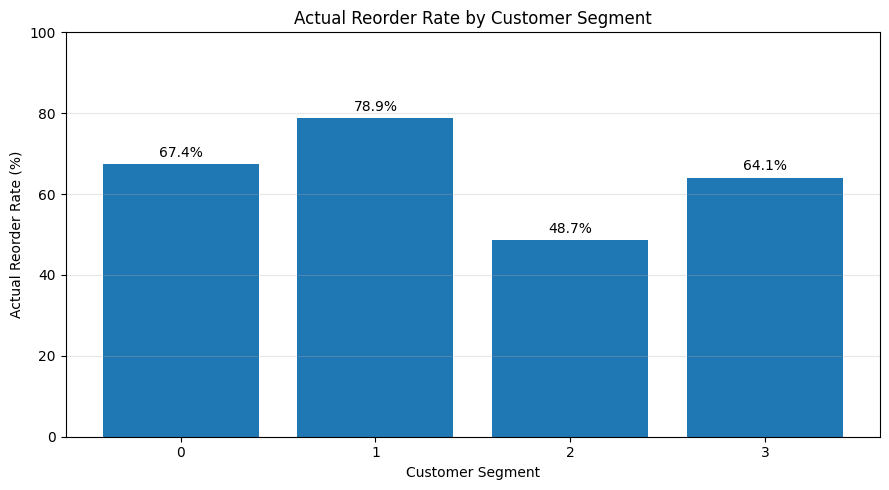

In [33]:
# ============================================================
# STEP 26: VISUALIZE ACTUAL REORDER RATE BY CLUSTER
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    validation_summary["cluster"].astype(str),
    validation_summary["Actual_Reorder_Rate_%"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Actual Reorder Rate (%)")
plt.title(
    "Actual Reorder Rate by Customer Segment"
)

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

# Add percentage labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 27. Visualizing Customer Segments

The four customer segments are visualized using the first two principal components and standardized behavioural profiles.

The PCA visualization provides a two-dimensional view of the separation between clusters, while the cluster-size chart shows the relative size of each segment.

A standardized behavioural profile is also created to compare the segments across key customer characteristics.

Because the behavioural variables have different units and scales, standardized cluster means are used for the profile comparison.

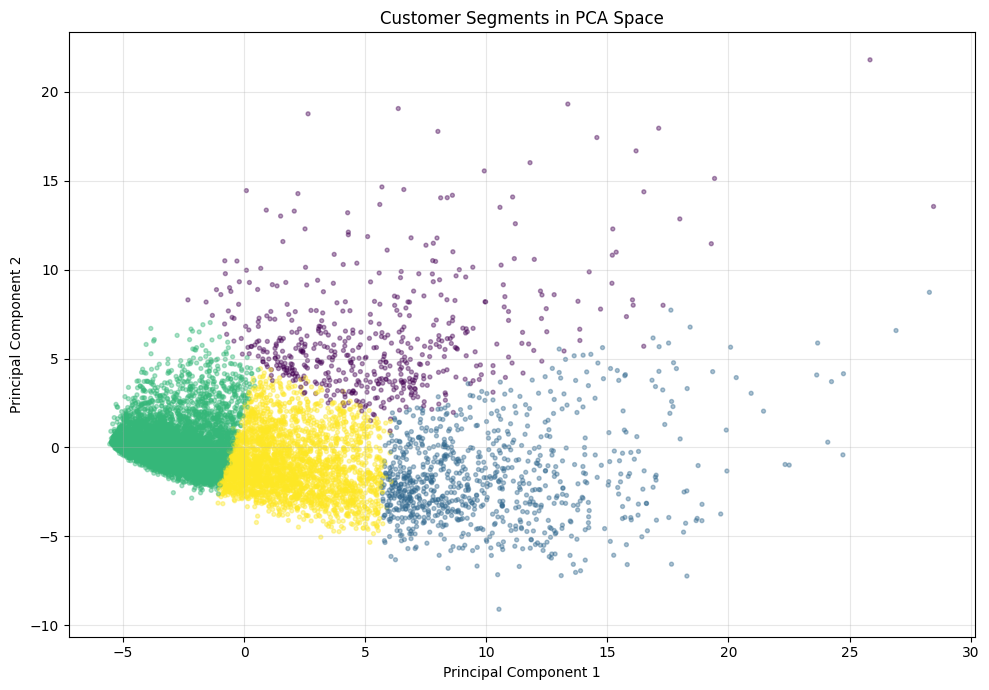

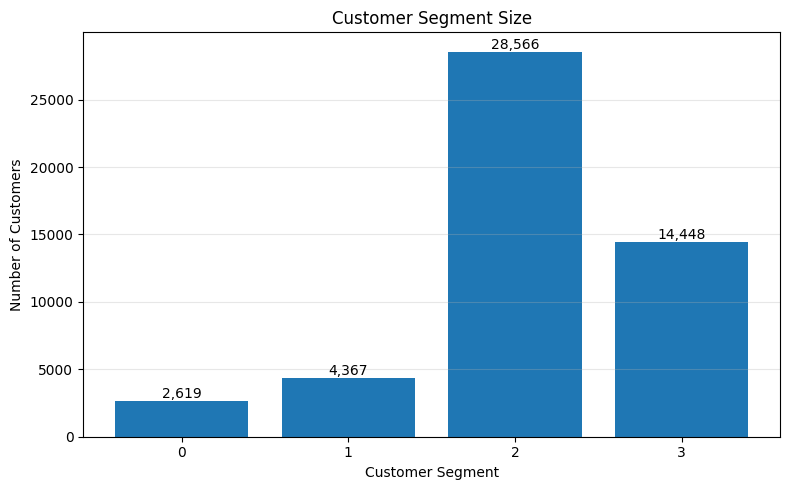

STANDARDIZED CLUSTER BEHAVIOURAL PROFILE


,total_orders,avg_days_between_orders,avg_order_hour,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
cluster,,,,,,,
0,0.26,-0.40,-0.14,0.21,0.20,-1.18,-0.49
1,1.46,-1.32,-1.53,1.19,1.37,0.72,-1.23
2,-1.26,1.42,0.48,-1.58,-1.43,-0.76,1.48
3,-0.46,0.30,1.19,0.19,-0.14,1.22,0.24


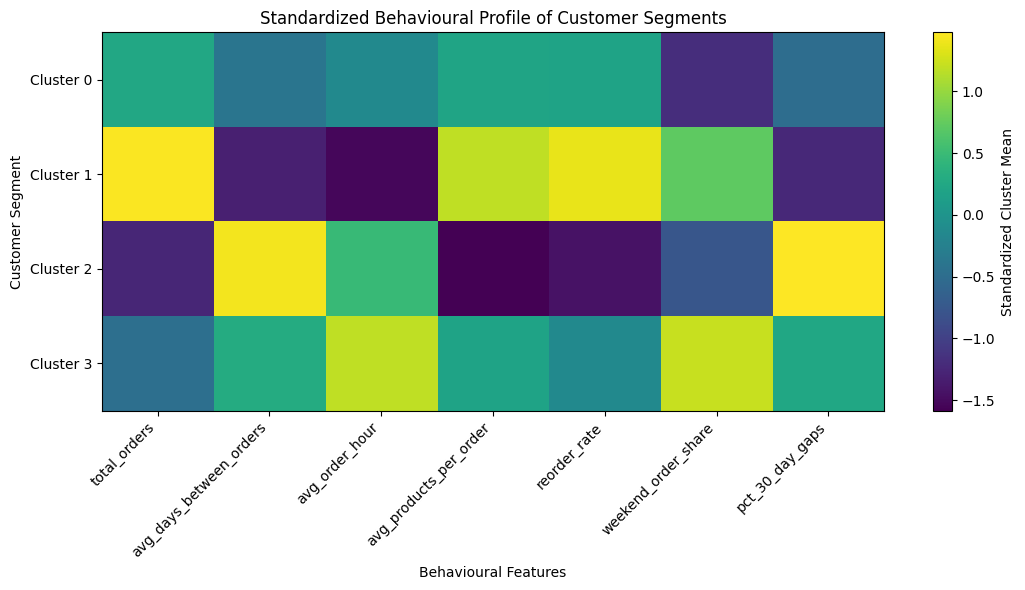

In [34]:
# ============================================================
# STEP 27: VISUALIZE THE FOUR CUSTOMER SEGMENTS
# ============================================================

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. PCA 1 vs PCA 2 scatter plot
# ------------------------------------------------------------

rng = np.random.default_rng(42)

plot_size = 10_000

plot_indices = rng.choice(
    len(X_final),
    size=plot_size,
    replace=False
)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_final[plot_indices, 0],
    X_final[plot_indices, 1],
    c=final_labels[plot_indices],
    s=8,
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments in PCA Space")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Cluster size chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

cluster_size_plot = (
    segmented_customers["cluster"]
    .value_counts()
    .sort_index()
)

bars = plt.bar(
    cluster_size_plot.index.astype(str),
    cluster_size_plot.values
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Size")

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Standardized behavioural profile
# ------------------------------------------------------------

profile_mean = (
    segmented_customers
    .groupby("cluster")[profile_features]
    .mean()
)

profile_scaler = StandardScaler()

profile_standardized = pd.DataFrame(
    profile_scaler.fit_transform(profile_mean),
    index=profile_mean.index,
    columns=profile_mean.columns
)

print("=" * 80)
print("STANDARDIZED CLUSTER BEHAVIOURAL PROFILE")
print("=" * 80)

display(
    profile_standardized.round(2)
)


# ------------------------------------------------------------
# 4. Behavioural profile heatmap
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.imshow(
    profile_standardized,
    aspect="auto"
)

plt.xticks(
    range(len(profile_features)),
    profile_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_standardized)),
    [
        f"Cluster {i}"
        for i in profile_standardized.index
    ]
)

plt.xlabel("Behavioural Features")
plt.ylabel("Customer Segment")
plt.title(
    "Standardized Behavioural Profile of Customer Segments"
)

plt.colorbar(
    label="Standardized Cluster Mean"
)

plt.tight_layout()
plt.show()

## 28. Business Interpretation of Customer Segments

Based on the behavioural profiles and independent reorder validation, descriptive business labels are assigned to the four clusters.

The labels are assigned after model fitting and are not used as inputs to the clustering algorithm.

The segments represent different combinations of purchase frequency, replenishment behaviour, basket size, weekend shopping preference, and long-order-gap behaviour.

## 28. Business Interpretation of Customer Segments

Based on the behavioural profiles and independent reorder validation, descriptive business labels are assigned to the four clusters.

The labels are assigned after model fitting and are not used as inputs to the clustering algorithm.

The segments represent different combinations of purchase frequency, replenishment behaviour, basket size, weekend shopping preference, and long-order-gap behaviour.

In [35]:
# ============================================================
# STEP 28: ASSIGN BUSINESS SEGMENT LABELS
# ============================================================

segment_labels = {
    0: "Frequent Loyal Shoppers",
    1: "High-Frequency Loyal Replenishers",
    2: "Occasional Low-Reorder Shoppers",
    3: "Moderate Weekend-Oriented Shoppers"
}

# ------------------------------------------------------------
# Add business segment name
# ------------------------------------------------------------

segmented_customers["segment_name"] = (
    segmented_customers["cluster"]
    .map(segment_labels)
)

# ------------------------------------------------------------
# Create report-ready segment profile
# ------------------------------------------------------------

final_segment_profile = (
    segmented_customers
    .groupby(
        ["cluster", "segment_name"]
    )
    .agg(
        Customer_Count=("user_id", "count"),
        Avg_Total_Orders=("total_orders", "mean"),
        Avg_Days_Between_Orders=(
            "avg_days_between_orders",
            "mean"
        ),
        Avg_Order_Hour=("avg_order_hour", "mean"),
        Avg_Products_Per_Order=(
            "avg_products_per_order",
            "mean"
        ),
        Historical_Reorder_Rate=(
            "reorder_rate",
            "mean"
        ),
        Weekend_Order_Share=(
            "weekend_order_share",
            "mean"
        ),
        Pct_30_Day_Gaps=(
            "pct_30_day_gaps",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# Add customer percentage
# ------------------------------------------------------------

final_segment_profile["Customer_Percentage"] = (
    final_segment_profile["Customer_Count"]
    / len(segmented_customers)
    * 100
)

# ------------------------------------------------------------
# Add actual validated reorder rate
# ------------------------------------------------------------

actual_reorder_lookup = (
    validation_summary
    .set_index("cluster")[
        "Actual_Reorder_Rate_%"
    ]
)

final_segment_profile["Actual_Train_Reorder_Rate_%"] = (
    final_segment_profile["cluster"]
    .map(actual_reorder_lookup)
)

# ------------------------------------------------------------
# Display final profile
# ------------------------------------------------------------

print("=" * 100)
print("FINAL CUSTOMER SEGMENT PROFILE")
print("=" * 100)

display(
    final_segment_profile.round(3)
)

# ------------------------------------------------------------
# Display concise report-ready version
# ------------------------------------------------------------

report_segment_profile = final_segment_profile[
    [
        "cluster",
        "segment_name",
        "Customer_Count",
        "Customer_Percentage",
        "Avg_Total_Orders",
        "Avg_Days_Between_Orders",
        "Avg_Products_Per_Order",
        "Historical_Reorder_Rate",
        "Actual_Train_Reorder_Rate_%",
        "Weekend_Order_Share",
        "Pct_30_Day_Gaps"
    ]
].copy()

print("\n" + "=" * 100)
print("REPORT-READY SEGMENT SUMMARY")
print("=" * 100)

display(
    report_segment_profile.round(3)
)

FINAL CUSTOMER SEGMENT PROFILE


,cluster,segment_name,Customer_Count,Avg_Total_Orders,Avg_Days_Between_Orders,Avg_Order_Hour,Avg_Products_Per_Order,Historical_Reorder_Rate,Weekend_Order_Share,Pct_30_Day_Gaps,Customer_Percentage,Actual_Train_Reorder_Rate_%
0,0,Frequent Loyal Shoppers,2619,28.494,11.438,13.561,12.627,0.533,0.301,0.090,5.238,67.419
1,1,High-Frequency Loyal Replenishers,4367,44.740,8.452,13.468,15.435,0.662,0.334,0.035,8.734,78.890
2,2,Occasional Low-Reorder Shoppers,28566,8.140,17.367,13.602,7.501,0.354,0.309,0.238,57.132,48.692
3,3,Moderate Weekend-Oriented Shoppers,14448,18.787,13.706,13.650,12.584,0.497,0.343,0.145,28.896,64.092



REPORT-READY SEGMENT SUMMARY


,cluster,segment_name,Customer_Count,Customer_Percentage,Avg_Total_Orders,Avg_Days_Between_Orders,Avg_Products_Per_Order,Historical_Reorder_Rate,Actual_Train_Reorder_Rate_%,Weekend_Order_Share,Pct_30_Day_Gaps
0,0,Frequent Loyal Shoppers,2619,5.238,28.494,11.438,12.627,0.533,67.419,0.301,0.090
1,1,High-Frequency Loyal Replenishers,4367,8.734,44.740,8.452,15.435,0.662,78.890,0.334,0.035
2,2,Occasional Low-Reorder Shoppers,28566,57.132,8.140,17.367,7.501,0.354,48.692,0.309,0.238
3,3,Moderate Weekend-Oriented Shoppers,14448,28.896,18.787,13.706,12.584,0.497,64.092,0.343,0.145


## 28. Hierarchical Clustering Cross-Check

Agglomerative Hierarchical Clustering is applied as an independent structural validation of the customer segmentation obtained using K-Means.

The same sampled customers and 10-component PCA representation used in the final K-Means analysis are retained to ensure a fair comparison between clustering approaches.

Ward linkage is used because it seeks to minimize within-cluster variance when merging observations.

The analysis will evaluate different numbers of clusters using silhouette scores and subsequently compare the hierarchical solution with the K-Means segmentation.

In [36]:
# ============================================================
# STEP 28A: IDENTIFY PCA DATA AVAILABLE FOR HIERARCHICAL
# CLUSTERING
# ============================================================

print("=" * 70)
print("AVAILABLE PCA / CLUSTERING VARIABLES")
print("=" * 70)

# Take a snapshot of the current variables
workspace = list(globals().items())

for name, value in workspace:

    if name.startswith("_"):
        continue

    try:
        shape = value.shape

        # Show likely PCA / clustering objects
        if (
            "pca" in name.lower()
            or "component" in name.lower()
            or "cluster" in name.lower()
            or (len(shape) == 2 and shape[0] == 50000)
        ):
            print(f"{name:<40} shape = {shape}")

    except (AttributeError, TypeError):
        pass

print("\n" + "=" * 70)
print("LOOK FOR A VARIABLE WITH SHAPE (50000, 10)")
print("That should be the 10-component PCA representation.")
print("=" * 70)

AVAILABLE PCA / CLUSTERING VARIABLES
sampled_customer_features                shape = (50000, 15)
aisle_purchase_matrix                    shape = (50000, 134)
aisle_purchase_share                     shape = (50000, 134)
aisle_share_scaled                       shape = (50000, 134)
X_pca_full                               shape = (50000, 134)
pca_summary                              shape = (134, 3)
aisle_counts_log                         shape = (50000, 134)
aisle_counts_log_scaled                  shape = (50000, 134)
X_pca_log                                shape = (50000, 134)
pca_log_summary                          shape = (134, 3)
pca_dimension_summary                    shape = (7, 4)
X_candidate                              shape = (50000, 40)
cluster_counts                           shape = (8,)
smallest_cluster_pct                     shape = ()
largest_cluster_pct                      shape = ()
X_clustering                             shape = (50000, 10)
X_final         

## 28. Hierarchical (Agglomerative) Clustering Cross-Check

Agglomerative Hierarchical Clustering is applied as an independent validation of the K-Means segmentation.

The same 50,000 sampled customers and the same 10-component PCA representation used in the final K-Means model are used.

Ward linkage is selected because it aims to minimize within-cluster variance during the hierarchical merging process.

Solutions with different numbers of clusters are evaluated using the Silhouette Score. The results are then compared with the K-Means solution to assess whether a four-segment structure is reasonable.

In [37]:
# ============================================================
# CHECK WHETHER PROJECT VARIABLES ARE AVAILABLE IN COLAB
# ============================================================

required_variables = [
    "sampled_customer_features",
    "aisle_purchase_matrix",
    "aisle_purchase_share",
    "aisle_share_scaled",
    "X_pca_full",
    "X_pca_log",
    "X_final",
    "segmented_customers"
]

print("=" * 70)
print("PROJECT VARIABLE CHECK")
print("=" * 70)

for var in required_variables:
    if var in globals():
        try:
            print(f"✓ {var:<30} shape = {globals()[var].shape}")
        except:
            print(f"✓ {var:<30} available")
    else:
        print(f"✗ {var:<30} NOT AVAILABLE")

print("=" * 70)

PROJECT VARIABLE CHECK
✓ sampled_customer_features      shape = (50000, 15)
✓ aisle_purchase_matrix          shape = (50000, 134)
✓ aisle_purchase_share           shape = (50000, 134)
✓ aisle_share_scaled             shape = (50000, 134)
✓ X_pca_full                     shape = (50000, 134)
✓ X_pca_log                      shape = (50000, 134)
✓ X_final                        shape = (50000, 10)
✓ segmented_customers            shape = (50000, 17)


## 28. Hierarchical (Agglomerative) Clustering Cross-Check

Agglomerative Hierarchical Clustering is applied as an independent structural validation of the K-Means customer segmentation.

The same 10-component PCA representation used in the final K-Means model is retained. A fixed representative sample of customers is used because hierarchical clustering is substantially more computationally intensive than K-Means.

Ward linkage with Euclidean distance is used to evaluate alternative cluster counts. Silhouette scores and cluster-size distributions are examined to assess whether the four-segment structure identified by K-Means is also supported by hierarchical clustering.

The hierarchical analysis is used as a cross-check and does not replace the final K-Means segmentation.

In [38]:
# ============================================================
# STEP 28B: AGGLOMERATIVE CLUSTERING CROSS-CHECK
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

print("=" * 80)
print("AGGLOMERATIVE CLUSTERING CROSS-CHECK")
print("=" * 80)

# ------------------------------------------------------------
# 1. Use the same PCA representation as final K-Means
# ------------------------------------------------------------

X_hierarchical_full = X_final

print("\nFull PCA representation:")
print(X_hierarchical_full.shape)

# ------------------------------------------------------------
# 2. Select a fixed representative sample
# ------------------------------------------------------------

HIERARCHICAL_SAMPLE_SIZE = 5000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

hier_indices = rng.choice(
    len(X_hierarchical_full),
    size=HIERARCHICAL_SAMPLE_SIZE,
    replace=False
)

X_hierarchical = X_hierarchical_full[hier_indices]

print("\nHierarchical clustering sample:")
print(X_hierarchical.shape)

print("Random state:", RANDOM_STATE)

# ------------------------------------------------------------
# 3. Evaluate alternative numbers of clusters
# ------------------------------------------------------------

k_values_hierarchical = [2, 3, 4, 5, 6]

hierarchical_results = []

for k in k_values_hierarchical:

    print("\n" + "-" * 70)
    print(f"Running Agglomerative Clustering: K={k}")
    print("-" * 70)

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_hierarchical
    )

    # --------------------------------------------------------
    # Silhouette score
    # --------------------------------------------------------

    silhouette = silhouette_score(
        X_hierarchical,
        labels
    )

    # --------------------------------------------------------
    # Cluster sizes
    # --------------------------------------------------------

    counts = np.bincount(labels)

    smallest_pct = (
        counts.min()
        / len(labels)
        * 100
    )

    largest_pct = (
        counts.max()
        / len(labels)
        * 100
    )

    print(
        f"Silhouette: {silhouette:.4f} | "
        f"Smallest cluster: {smallest_pct:.2f}% | "
        f"Largest cluster: {largest_pct:.2f}%"
    )

    hierarchical_results.append({
        "K": k,
        "Silhouette_Score": silhouette,
        "Smallest_Cluster_%": smallest_pct,
        "Largest_Cluster_%": largest_pct
    })


# ------------------------------------------------------------
# 4. Create results table
# ------------------------------------------------------------

hierarchical_results_df = pd.DataFrame(
    hierarchical_results
)

print("\n" + "=" * 80)
print("AGGLOMERATIVE CLUSTERING RESULTS")
print("=" * 80)

display(
    hierarchical_results_df.round(4)
)


# ------------------------------------------------------------
# 5. Identify best hierarchical solution
# ------------------------------------------------------------

best_hierarchical = hierarchical_results_df.loc[
    hierarchical_results_df["Silhouette_Score"].idxmax()
]

print("\n" + "=" * 80)
print("BEST HIERARCHICAL SOLUTION")
print("=" * 80)

print(
    f"K = {int(best_hierarchical['K'])}"
)

print(
    f"Silhouette Score = "
    f"{best_hierarchical['Silhouette_Score']:.4f}"
)

AGGLOMERATIVE CLUSTERING CROSS-CHECK

Full PCA representation:
(50000, 10)

Hierarchical clustering sample:
(5000, 10)
Random state: 42

----------------------------------------------------------------------
Running Agglomerative Clustering: K=2
----------------------------------------------------------------------
Silhouette: 0.4613 | Smallest cluster: 14.08% | Largest cluster: 85.92%

----------------------------------------------------------------------
Running Agglomerative Clustering: K=3
----------------------------------------------------------------------
Silhouette: 0.1873 | Smallest cluster: 14.08% | Largest cluster: 43.38%

----------------------------------------------------------------------
Running Agglomerative Clustering: K=4
----------------------------------------------------------------------
Silhouette: 0.1980 | Smallest cluster: 4.78% | Largest cluster: 43.38%

----------------------------------------------------------------------
Running Agglomerative Clustering: 

,K,Silhouette_Score,Smallest_Cluster_%,Largest_Cluster_%
0,2,0.4613,14.08,85.92
1,3,0.1873,14.08,43.38
2,4,0.1980,4.78,43.38
3,5,0.2073,3.70,43.38
4,6,0.1521,3.70,43.38



BEST HIERARCHICAL SOLUTION
K = 2
Silhouette Score = 0.4613


## 29. K-Means vs Hierarchical Clustering Comparison

The four-cluster Agglomerative solution is compared with the final K-Means segmentation using the same customer sample and PCA representation.

Because cluster labels are arbitrary, direct comparison of numeric cluster labels is not appropriate. Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) are therefore used to measure the similarity between the two clustering solutions.

The comparison helps determine whether the four-segment structure is reasonably stable across different clustering algorithms.

In [40]:
# ============================================================
# STEP 29: K-MEANS VS HIERARCHICAL K=4 COMPARISON
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

print("=" * 80)
print("K-MEANS VS HIERARCHICAL CLUSTERING — K=4")
print("=" * 80)

# ------------------------------------------------------------
# 1. Obtain K-Means labels for the same hierarchical sample
# ------------------------------------------------------------

# Final K-Means labels are stored in segmented_customers
print("\nSegmented customer dataset shape:")
print(segmented_customers.shape)

print("\nSegmented customer columns:")
print(segmented_customers.columns.tolist())

# Find the cluster column
cluster_column_candidates = [
    col for col in segmented_customers.columns
    if col.lower() in ["cluster", "cluster_id", "kmeans_cluster"]
]

print("\nPossible cluster columns:")
print(cluster_column_candidates)

# Use the first matching cluster column
kmeans_cluster_column = cluster_column_candidates[0]

kmeans_labels_sample = (
    segmented_customers.iloc[hier_indices][kmeans_cluster_column]
    .to_numpy()
)

print("\nK-Means cluster column used:")
print(kmeans_cluster_column)

# ------------------------------------------------------------
# 2. Fit hierarchical clustering with K=4
# ------------------------------------------------------------

hierarchical_model_k4 = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels_k4 = hierarchical_model_k4.fit_predict(
    X_hierarchical
)

# ------------------------------------------------------------
# 3. Calculate agreement metrics
# ------------------------------------------------------------

ari_score = adjusted_rand_score(
    kmeans_labels_sample,
    hierarchical_labels_k4
)

nmi_score = normalized_mutual_info_score(
    kmeans_labels_sample,
    hierarchical_labels_k4
)

print("\n" + "=" * 80)
print("CLUSTERING AGREEMENT")
print("=" * 80)

print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

# ------------------------------------------------------------
# 4. Cluster size comparison
# ------------------------------------------------------------

kmeans_counts = np.bincount(
    kmeans_labels_sample
)

hierarchical_counts = np.bincount(
    hierarchical_labels_k4
)

comparison = pd.DataFrame({
    "KMeans_Count": kmeans_counts,
    "KMeans_%": (
        kmeans_counts / len(kmeans_labels_sample) * 100
    ),
    "Hierarchical_Count": hierarchical_counts,
    "Hierarchical_%": (
        hierarchical_counts / len(hierarchical_labels_k4) * 100
    )
})

comparison.index.name = "Cluster"

print("\n" + "=" * 80)
print("CLUSTER SIZE COMPARISON")
print("=" * 80)

display(
    comparison.round(2)
)

K-MEANS VS HIERARCHICAL CLUSTERING — K=4

Segmented customer dataset shape:
(50000, 17)

Segmented customer columns:
['user_id', 'total_orders', 'avg_days_between_orders', 'median_days_between_orders', 'min_days_between_orders', 'max_days_between_orders', 'avg_order_dow', 'avg_order_hour', 'total_products', 'total_reordered_products', 'orders_with_products', 'avg_products_per_order', 'reorder_rate', 'weekend_order_share', 'pct_30_day_gaps', 'cluster', 'segment_name']

Possible cluster columns:
['cluster']

K-Means cluster column used:
cluster

CLUSTERING AGREEMENT
Adjusted Rand Index (ARI): 0.5068
Normalized Mutual Information (NMI): 0.5191

CLUSTER SIZE COMPARISON


,KMeans_Count,KMeans_%,Hierarchical_Count,Hierarchical_%
Cluster,,,,
0,283,5.66,2127,42.54
1,438,8.76,239,4.78
2,2834,56.68,2169,43.38
3,1445,28.90,465,9.30


## 30. Hierarchical Clustering Dendrogram

A dendrogram is generated using a small representative sample of customers to visualize the hierarchical merging process.

The dendrogram is used for structural interpretation rather than for estimating the complete customer population. A smaller sample is intentionally used because displaying hierarchical relationships for tens of thousands of observations would be computationally expensive and visually unreadable.

Ward linkage is used consistently with the Agglomerative Clustering analysis.

HIERARCHICAL CLUSTERING DENDROGRAM

Dendrogram sample shape:
(300, 10)

Computing Ward linkage...
Linkage matrix shape:
(299, 4)


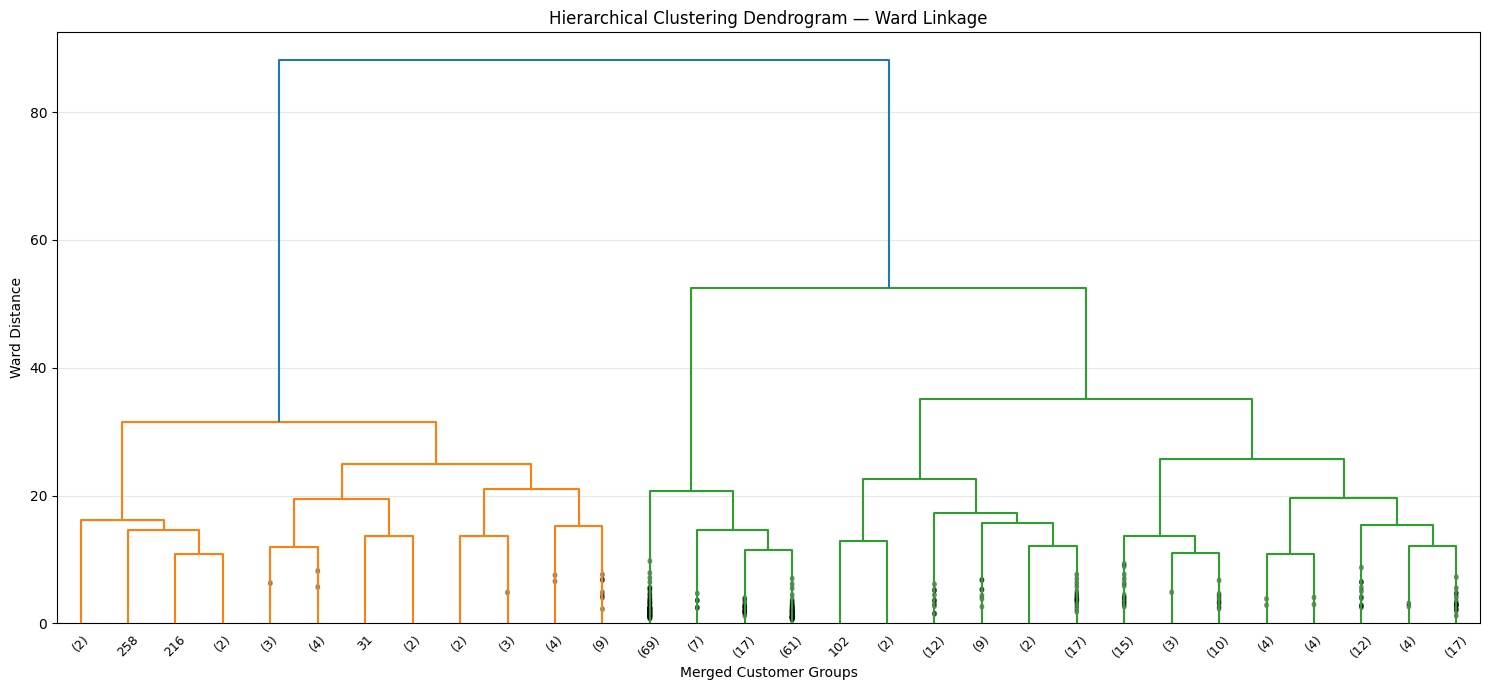


Dendrogram generated successfully.


In [42]:
# ============================================================
# STEP 30: HIERARCHICAL CLUSTERING DENDROGRAM
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage

print("=" * 80)
print("HIERARCHICAL CLUSTERING DENDROGRAM")
print("=" * 80)

# ------------------------------------------------------------
# Use a small representative sample
# ------------------------------------------------------------

DENDROGRAM_SAMPLE_SIZE = 300
RANDOM_STATE = 42

rng_dendro = np.random.default_rng(RANDOM_STATE)

dendro_indices = rng_dendro.choice(
    len(X_final),
    size=DENDROGRAM_SAMPLE_SIZE,
    replace=False
)

X_dendrogram = X_final[dendro_indices]

print("\nDendrogram sample shape:")
print(X_dendrogram.shape)

# ------------------------------------------------------------
# Ward linkage
# ------------------------------------------------------------

print("\nComputing Ward linkage...")

linkage_matrix = linkage(
    X_dendrogram,
    method="ward",
    metric="euclidean"
)

print("Linkage matrix shape:")
print(linkage_matrix.shape)

# ------------------------------------------------------------
# Plot dendrogram
# ------------------------------------------------------------

plt.figure(figsize=(15, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    show_contracted=True
)

plt.title(
    "Hierarchical Clustering Dendrogram — Ward Linkage"
)

plt.xlabel(
    "Merged Customer Groups"
)

plt.ylabel(
    "Ward Distance"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("\nDendrogram generated successfully.")

## 31. Gaussian Mixture Model (GMM)

A Gaussian Mixture Model is applied as a probabilistic clustering approach to complement the K-Means and Agglomerative Clustering methods.

Unlike K-Means, GMM assigns each customer a probability of membership across all clusters. This allows identification of customers with strong segment membership as well as customers whose behaviour lies between segments.

The 10-component PCA representation is used as the input to maintain consistency with the final K-Means model.

In [43]:
# ============================================================
# STEP 31: GAUSSIAN MIXTURE MODEL VALIDATION
# ============================================================

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("GAUSSIAN MIXTURE MODEL VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Input data
# ------------------------------------------------------------

X_gmm = X_final

print("\nGMM input shape:")
print(X_gmm.shape)

# ------------------------------------------------------------
# Test different numbers of components
# ------------------------------------------------------------

gmm_components = [2, 3, 4, 5, 6]

# Use a sample for silhouette calculation
silhouette_sample_size = 10000

rng = np.random.default_rng(42)

if len(X_gmm) > silhouette_sample_size:
    silhouette_indices = rng.choice(
        len(X_gmm),
        size=silhouette_sample_size,
        replace=False
    )
else:
    silhouette_indices = np.arange(len(X_gmm))

X_gmm_silhouette = X_gmm[silhouette_indices]

gmm_results = []

for k in gmm_components:

    print("\n" + "-" * 70)
    print(f"Running GMM: K={k}")
    print("-" * 70)

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=3
    )

    gmm.fit(X_gmm)

    labels = gmm.predict(X_gmm)

    # BIC and AIC
    bic = gmm.bic(X_gmm)
    aic = gmm.aic(X_gmm)

    # Silhouette on sample
    sample_labels = labels[silhouette_indices]

    if len(np.unique(sample_labels)) > 1:
        silhouette = silhouette_score(
            X_gmm_silhouette,
            sample_labels
        )
    else:
        silhouette = np.nan

    # Cluster sizes
    counts = np.bincount(labels, minlength=k)

    cluster_percentages = (
        counts / len(labels) * 100
    )

    smallest_cluster = cluster_percentages.min()
    largest_cluster = cluster_percentages.max()

    print(
        f"BIC: {bic:,.2f} | "
        f"AIC: {aic:,.2f} | "
        f"Silhouette: {silhouette:.4f}"
    )

    print(
        f"Smallest cluster: {smallest_cluster:.2f}% | "
        f"Largest cluster: {largest_cluster:.2f}%"
    )

    gmm_results.append({
        "K": k,
        "BIC": bic,
        "AIC": aic,
        "Silhouette": silhouette,
        "Smallest_Cluster_%": smallest_cluster,
        "Largest_Cluster_%": largest_cluster
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

gmm_results_df = pd.DataFrame(gmm_results)

print("\n" + "=" * 80)
print("GMM VALIDATION RESULTS")
print("=" * 80)

display(
    gmm_results_df.sort_values(
        "BIC"
    ).reset_index(drop=True)
)

# ------------------------------------------------------------
# Best configurations
# ------------------------------------------------------------

best_bic = gmm_results_df.loc[
    gmm_results_df["BIC"].idxmin()
]

best_aic = gmm_results_df.loc[
    gmm_results_df["AIC"].idxmin()
]

best_silhouette = gmm_results_df.loc[
    gmm_results_df["Silhouette"].idxmax()
]

print("\n" + "=" * 80)
print("BEST GMM CONFIGURATIONS")
print("=" * 80)

print(
    f"\nLowest BIC: "
    f"K={int(best_bic['K'])}, "
    f"BIC={best_bic['BIC']:,.2f}"
)

print(
    f"Lowest AIC: "
    f"K={int(best_aic['K'])}, "
    f"AIC={best_aic['AIC']:,.2f}"
)

print(
    f"Highest Silhouette: "
    f"K={int(best_silhouette['K'])}, "
    f"Silhouette={best_silhouette['Silhouette']:.4f}"
)

GAUSSIAN MIXTURE MODEL VALIDATION

GMM input shape:
(50000, 10)

----------------------------------------------------------------------
Running GMM: K=2
----------------------------------------------------------------------
BIC: 1,595,505.58 | AIC: 1,594,350.19 | Silhouette: 0.2906
Smallest cluster: 36.68% | Largest cluster: 63.32%

----------------------------------------------------------------------
Running GMM: K=3
----------------------------------------------------------------------
BIC: 1,509,772.41 | AIC: 1,508,034.92 | Silhouette: 0.1044
Smallest cluster: 18.72% | Largest cluster: 43.93%

----------------------------------------------------------------------
Running GMM: K=4
----------------------------------------------------------------------
BIC: 1,470,947.57 | AIC: 1,468,627.97 | Silhouette: 0.0599
Smallest cluster: 9.77% | Largest cluster: 41.51%

----------------------------------------------------------------------
Running GMM: K=5
--------------------------------------

,K,BIC,AIC,Silhouette,Smallest_Cluster_%,Largest_Cluster_%
0,6,1.433776e+06,1.430292e+06,0.032952,5.806,34.776
1,5,1.448225e+06,1.445323e+06,-0.005493,9.042,33.806
2,4,1.470948e+06,1.468628e+06,0.059861,9.770,41.506
3,3,1.509772e+06,1.508035e+06,0.104368,18.722,43.930
4,2,1.595506e+06,1.594350e+06,0.290644,36.678,63.322



BEST GMM CONFIGURATIONS

Lowest BIC: K=6, BIC=1,433,775.56
Lowest AIC: K=6, AIC=1,430,291.74
Highest Silhouette: K=2, Silhouette=0.2906


GMM PROBABILISTIC MEMBERSHIP ANALYSIS — K=4

GMM labels shape:
(50000,)

GMM probability matrix shape:
(50000, 4)

GMM MEMBERSHIP CONFIDENCE

High confidence (>=80%): 43,888 (87.78%)
Medium confidence (60%-80%): 3,943 (7.89%)
Low confidence (<60%): 2,169 (4.34%)

Mean maximum membership probability: 0.9375
Median maximum membership probability: 0.9955
Minimum maximum membership probability: 0.3490
Maximum maximum membership probability: 1.0000

GMM K=4 CLUSTER SIZE


,GMM_Cluster,Customer_Count,Percentage
0,0,14867,29.734
1,1,9495,18.990
2,2,20753,41.506
3,3,4885,9.770



GMM PROBABILITY SUMMARY


,GMM_Probability_0,GMM_Probability_1,GMM_Probability_2,GMM_Probability_3
count,50000.0000,50000.0000,50000.0000,50000.0000
mean,0.2945,0.1914,0.4105,0.1036
std,0.4351,0.3645,0.4527,0.2833
min,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0002,0.0000
50%,0.0000,0.0005,0.0747,0.0002
75%,0.9121,0.0682,0.9817,0.0036
max,0.9999,1.0000,0.9998,1.0000


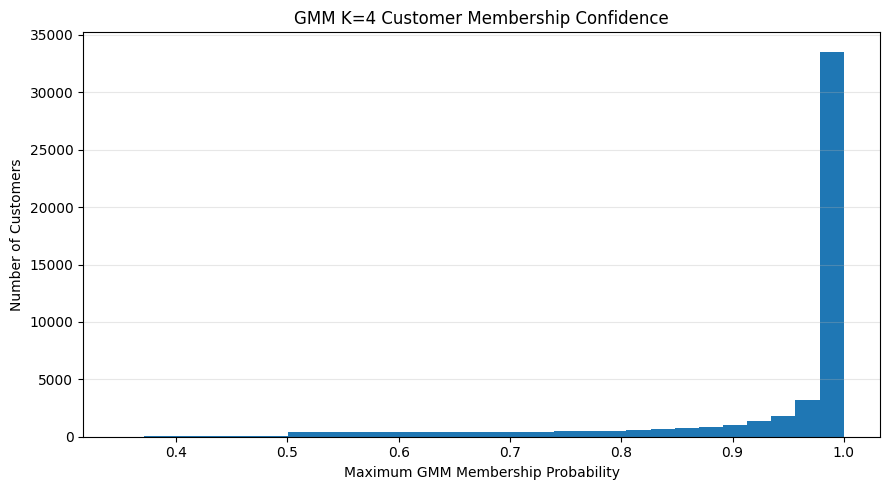


GMM membership dataset shape:
(50000, 4)

First 10 GMM membership records:


,gmm_cluster,max_membership_probability,second_highest_probability,membership_margin
0,2,0.539777,4.565158e-01,0.083261
1,0,0.988799,1.119501e-02,0.977604
2,3,1.000000,1.015649e-18,1.000000
3,0,0.990609,9.381668e-03,0.981228
4,2,0.997841,1.603551e-03,0.996237
5,1,0.999979,2.125603e-05,0.999957
6,2,0.997573,2.128385e-03,0.995445
7,2,0.999068,8.876485e-04,0.998180
8,3,1.000000,2.517134e-12,1.000000
9,3,1.000000,2.928612e-46,1.000000


In [44]:
# ============================================================
# STEP 32: GMM PROBABILISTIC MEMBERSHIP ANALYSIS — K=4
# ============================================================

from sklearn.mixture import GaussianMixture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("GMM PROBABILISTIC MEMBERSHIP ANALYSIS — K=4")
print("=" * 80)

# ------------------------------------------------------------
# Fit final comparison GMM with K=4
# ------------------------------------------------------------

gmm_4 = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
    n_init=3
)

gmm_4.fit(X_final)

# Hard GMM assignment
gmm_labels = gmm_4.predict(X_final)

# Membership probabilities
gmm_probabilities = gmm_4.predict_proba(X_final)

print("\nGMM labels shape:")
print(gmm_labels.shape)

print("\nGMM probability matrix shape:")
print(gmm_probabilities.shape)

# ------------------------------------------------------------
# Maximum membership probability
# ------------------------------------------------------------

max_membership_probability = gmm_probabilities.max(axis=1)

# Second highest probability
sorted_probabilities = np.sort(
    gmm_probabilities,
    axis=1
)

second_highest_probability = sorted_probabilities[:, -2]

# Membership margin
membership_margin = (
    max_membership_probability
    - second_highest_probability
)

# ------------------------------------------------------------
# Confidence categories
# ------------------------------------------------------------

high_confidence = (
    max_membership_probability >= 0.80
)

medium_confidence = (
    (max_membership_probability >= 0.60)
    &
    (max_membership_probability < 0.80)
)

low_confidence = (
    max_membership_probability < 0.60
)

print("\n" + "=" * 80)
print("GMM MEMBERSHIP CONFIDENCE")
print("=" * 80)

print(
    f"\nHigh confidence (>=80%): "
    f"{high_confidence.sum():,} "
    f"({high_confidence.mean()*100:.2f}%)"
)

print(
    f"Medium confidence (60%-80%): "
    f"{medium_confidence.sum():,} "
    f"({medium_confidence.mean()*100:.2f}%)"
)

print(
    f"Low confidence (<60%): "
    f"{low_confidence.sum():,} "
    f"({low_confidence.mean()*100:.2f}%)"
)

print(
    f"\nMean maximum membership probability: "
    f"{max_membership_probability.mean():.4f}"
)

print(
    f"Median maximum membership probability: "
    f"{np.median(max_membership_probability):.4f}"
)

print(
    f"Minimum maximum membership probability: "
    f"{max_membership_probability.min():.4f}"
)

print(
    f"Maximum maximum membership probability: "
    f"{max_membership_probability.max():.4f}"
)

# ------------------------------------------------------------
# GMM cluster sizes
# ------------------------------------------------------------

gmm_cluster_counts = np.bincount(
    gmm_labels,
    minlength=4
)

gmm_cluster_percentages = (
    gmm_cluster_counts
    / len(gmm_labels)
    * 100
)

gmm_cluster_summary = pd.DataFrame({
    "GMM_Cluster": range(4),
    "Customer_Count": gmm_cluster_counts,
    "Percentage": gmm_cluster_percentages
})

print("\n" + "=" * 80)
print("GMM K=4 CLUSTER SIZE")
print("=" * 80)

display(gmm_cluster_summary)

# ------------------------------------------------------------
# Probability summary
# ------------------------------------------------------------

probability_summary = pd.DataFrame(
    gmm_probabilities,
    columns=[
        "GMM_Probability_0",
        "GMM_Probability_1",
        "GMM_Probability_2",
        "GMM_Probability_3"
    ]
)

print("\n" + "=" * 80)
print("GMM PROBABILITY SUMMARY")
print("=" * 80)

display(
    probability_summary.describe().round(4)
)

# ------------------------------------------------------------
# Plot membership confidence
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    max_membership_probability,
    bins=30
)

plt.xlabel("Maximum GMM Membership Probability")
plt.ylabel("Number of Customers")
plt.title(
    "GMM K=4 Customer Membership Confidence"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Store results for later comparison
# ------------------------------------------------------------

gmm_membership = pd.DataFrame({
    "gmm_cluster": gmm_labels,
    "max_membership_probability":
        max_membership_probability,
    "second_highest_probability":
        second_highest_probability,
    "membership_margin":
        membership_margin
})

print("\nGMM membership dataset shape:")
print(gmm_membership.shape)

print("\nFirst 10 GMM membership records:")
display(
    gmm_membership.head(10)
)

In [45]:
# ============================================================
# STEP 33: THREE-WAY CLUSTERING CONSISTENCY CHECK
# ============================================================

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd
import numpy as np

print("=" * 80)
print("THREE-WAY CLUSTERING CONSISTENCY CHECK — K=4")
print("=" * 80)

# ------------------------------------------------------------
# Existing K-Means labels
# ------------------------------------------------------------

kmeans_labels = segmented_customers["cluster"].values

print("\nK-Means labels:")
print("Shape:", kmeans_labels.shape)
print("Clusters:", np.unique(kmeans_labels))

# ------------------------------------------------------------
# Hierarchical K=4 on 5,000-customer sample
# ------------------------------------------------------------
# IMPORTANT:
# Your previous hierarchical clustering was performed on a
# 5,000-customer sample, so it cannot be directly compared
# with all 50,000 GMM/K-Means assignments.
#
# Therefore, use the same hierarchical sample if the variable
# already exists.

print("\nChecking available hierarchical variables...")

candidate_hierarchical_vars = [
    "hierarchical_labels_4",
    "agg_labels_4",
    "hierarchical_k4_labels",
    "agg_k4_labels"
]

available_hierarchical = [
    x for x in candidate_hierarchical_vars
    if x in globals()
]

print("Available hierarchical label variables:")
print(available_hierarchical)

# ------------------------------------------------------------
# GMM labels
# ------------------------------------------------------------

print("\nGMM labels:")
print("Shape:", gmm_labels.shape)
print("Clusters:", np.unique(gmm_labels))

# ------------------------------------------------------------
# K-Means vs GMM
# ------------------------------------------------------------

ari_kmeans_gmm = adjusted_rand_score(
    kmeans_labels,
    gmm_labels
)

nmi_kmeans_gmm = normalized_mutual_info_score(
    kmeans_labels,
    gmm_labels
)

print("\n" + "=" * 80)
print("K-MEANS VS GMM")
print("=" * 80)

print(f"ARI: {ari_kmeans_gmm:.4f}")
print(f"NMI: {nmi_kmeans_gmm:.4f}")

# ------------------------------------------------------------
# Cluster size comparison
# ------------------------------------------------------------

kmeans_counts = pd.Series(
    kmeans_labels
).value_counts().sort_index()

gmm_counts = pd.Series(
    gmm_labels
).value_counts().sort_index()

cluster_comparison = pd.DataFrame({
    "KMeans_Count": kmeans_counts,
    "KMeans_%": kmeans_counts / len(kmeans_labels) * 100,
    "GMM_Count": gmm_counts,
    "GMM_%": gmm_counts / len(gmm_labels) * 100
})

print("\n" + "=" * 80)
print("K-MEANS VS GMM CLUSTER SIZE COMPARISON")
print("=" * 80)

display(
    cluster_comparison.round(2)
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

comparison_summary = pd.DataFrame({
    "Comparison": [
        "K-Means vs Hierarchical",
        "K-Means vs GMM"
    ],
    "ARI": [
        0.5068,
        ari_kmeans_gmm
    ],
    "NMI": [
        0.5191,
        nmi_kmeans_gmm
    ]
})

print("\n" + "=" * 80)
print("CLUSTERING AGREEMENT SUMMARY")
print("=" * 80)

display(
    comparison_summary.round(4)
)

# ------------------------------------------------------------
# Final GMM confidence summary
# ------------------------------------------------------------

confidence_summary = pd.DataFrame({
    "Confidence_Level": [
        "High (>=80%)",
        "Medium (60%-80%)",
        "Low (<60%)"
    ],
    "Customers": [
        high_confidence.sum(),
        medium_confidence.sum(),
        low_confidence.sum()
    ],
    "Percentage": [
        high_confidence.mean() * 100,
        medium_confidence.mean() * 100,
        low_confidence.mean() * 100
    ]
})

print("\n" + "=" * 80)
print("GMM MEMBERSHIP CONFIDENCE SUMMARY")
print("=" * 80)

display(
    confidence_summary.round(2)
)

print("\n" + "=" * 80)
print("THREE-WAY CONSISTENCY CHECK COMPLETED")
print("=" * 80)

THREE-WAY CLUSTERING CONSISTENCY CHECK — K=4

K-Means labels:
Shape: (50000,)
Clusters: [0 1 2 3]

Checking available hierarchical variables...
Available hierarchical label variables:
[]

GMM labels:
Shape: (50000,)
Clusters: [0 1 2 3]

K-MEANS VS GMM
ARI: 0.2340
NMI: 0.3095

K-MEANS VS GMM CLUSTER SIZE COMPARISON


,KMeans_Count,KMeans_%,GMM_Count,GMM_%
0,2619,5.24,14867,29.73
1,4367,8.73,9495,18.99
2,28566,57.13,20753,41.51
3,14448,28.90,4885,9.77



CLUSTERING AGREEMENT SUMMARY


,Comparison,ARI,NMI
0,K-Means vs Hierarchical,0.5068,0.5191
1,K-Means vs GMM,0.2340,0.3095



GMM MEMBERSHIP CONFIDENCE SUMMARY


,Confidence_Level,Customers,Percentage
0,High (>=80%),43888,87.78
1,Medium (60%-80%),3943,7.89
2,Low (<60%),2169,4.34



THREE-WAY CONSISTENCY CHECK COMPLETED


In [46]:
# ============================================================
# STEP 34: FINAL K-MEANS K=4 CUSTOMER SEGMENT PROFILING
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("FINAL K-MEANS K=4 CUSTOMER SEGMENT PROFILING")
print("=" * 80)

# ------------------------------------------------------------
# Variables used for business interpretation
# ------------------------------------------------------------

profile_features = [
    "total_orders",
    "avg_days_between_orders",
    "median_days_between_orders",
    "total_products",
    "total_reordered_products",
    "orders_with_products",
    "avg_products_per_order",
    "reorder_rate",
    "weekend_order_share",
    "pct_30_day_gaps"
]

# Check availability
available_features = [
    col for col in profile_features
    if col in segmented_customers.columns
]

missing_features = [
    col for col in profile_features
    if col not in segmented_customers.columns
]

print("\nAvailable profiling variables:")
print(available_features)

if missing_features:
    print("\nMissing variables:")
    print(missing_features)

# ------------------------------------------------------------
# Cluster profile — MEAN
# ------------------------------------------------------------

cluster_profile_mean_final = (
    segmented_customers
    .groupby("cluster")[available_features]
    .mean()
    .round(3)
)

print("\n" + "=" * 80)
print("K-MEANS K=4 — MEAN CUSTOMER PROFILE")
print("=" * 80)

display(cluster_profile_mean_final)

# ------------------------------------------------------------
# Cluster profile — MEDIAN
# ------------------------------------------------------------

cluster_profile_median_final = (
    segmented_customers
    .groupby("cluster")[available_features]
    .median()
    .round(3)
)

print("\n" + "=" * 80)
print("K-MEANS K=4 — MEDIAN CUSTOMER PROFILE")
print("=" * 80)

display(cluster_profile_median_final)

# ------------------------------------------------------------
# Cluster sizes
# ------------------------------------------------------------

cluster_size_final = (
    segmented_customers["cluster"]
    .value_counts()
    .sort_index()
)

cluster_pct_final = (
    cluster_size_final /
    len(segmented_customers) * 100
)

cluster_summary_final = pd.DataFrame({
    "Customers": cluster_size_final,
    "Percentage": cluster_pct_final.round(2)
})

print("\n" + "=" * 80)
print("K-MEANS K=4 — SEGMENT SIZE")
print("=" * 80)

display(cluster_summary_final)

# ------------------------------------------------------------
# Overall comparison
# ------------------------------------------------------------

overall_mean = (
    segmented_customers[available_features]
    .mean()
)

print("\n" + "=" * 80)
print("CLUSTER VS OVERALL AVERAGE")
print("=" * 80)

# Percentage difference from overall mean
cluster_vs_overall = (
    cluster_profile_mean_final
    .divide(overall_mean, axis=1)
    .subtract(1)
    .multiply(100)
    .round(1)
)

display(cluster_vs_overall)

print("\n" + "=" * 80)
print("PROFILING COMPLETED")
print("=" * 80)

FINAL K-MEANS K=4 CUSTOMER SEGMENT PROFILING

Available profiling variables:
['total_orders', 'avg_days_between_orders', 'median_days_between_orders', 'total_products', 'total_reordered_products', 'orders_with_products', 'avg_products_per_order', 'reorder_rate', 'weekend_order_share', 'pct_30_day_gaps']

K-MEANS K=4 — MEAN CUSTOMER PROFILE


,total_orders,avg_days_between_orders,median_days_between_orders,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
cluster,,,,,,,,,,
0,28.494,11.438,10.150,314.703,189.507,28.494,12.627,0.533,0.301,0.090
1,44.740,8.452,7.046,618.613,432.091,44.741,15.435,0.662,0.334,0.035
2,8.140,17.367,17.418,51.101,21.903,8.140,7.501,0.354,0.309,0.238
3,18.787,13.706,12.725,194.497,109.174,18.787,12.584,0.497,0.343,0.145



K-MEANS K=4 — MEDIAN CUSTOMER PROFILE


,total_orders,avg_days_between_orders,median_days_between_orders,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
cluster,,,,,,,,,,
0,23.0,10.567,8.0,254.0,133.0,23.0,11.045,0.541,0.280,0.04
1,40.0,7.911,7.0,543.0,367.0,40.0,14.280,0.677,0.306,0.00
2,6.0,17.429,16.5,44.0,13.0,6.0,6.733,0.333,0.286,0.20
3,15.0,13.200,10.5,166.0,81.0,15.0,11.458,0.497,0.316,0.10



K-MEANS K=4 — SEGMENT SIZE


,Customers,Percentage
cluster,,
0,2619,5.24
1,4367,8.73
2,28566,57.13
3,14448,28.90



CLUSTER VS OVERALL AVERAGE


,total_orders,avg_days_between_orders,median_days_between_orders,total_products,total_reordered_products,orders_with_products,avg_products_per_order,reorder_rate,weekend_order_share,pct_30_day_gaps
cluster,,,,,,,,,,
0,84.1,-24.8,-31.3,101.8,106.6,84.1,27.1,23.5,-6.0,-51.5
1,189.0,-44.5,-52.3,296.8,371.1,189.0,55.4,53.3,4.3,-81.1
2,-47.4,14.1,17.9,-67.2,-76.1,-47.4,-24.5,-18.0,-3.5,28.4
3,21.4,-9.9,-13.9,24.7,19.0,21.4,26.7,15.1,7.1,-21.8



PROFILING COMPLETED


In [47]:
# ============================================================
# STEP 35: CREATE FINAL BUSINESS SEGMENT LABELS
# ============================================================

segment_mapping = {
    0: "High-Value Loyal Customers",
    1: "Champions / Most Loyal Customers",
    2: "Occasional / Low-Engagement Customers",
    3: "Regular / Moderate Customers"
}

segmented_customers["final_segment"] = (
    segmented_customers["cluster"]
    .map(segment_mapping)
)

print("=" * 80)
print("FINAL CUSTOMER SEGMENT LABELS")
print("=" * 80)

# ------------------------------------------------------------
# Segment counts
# ------------------------------------------------------------

final_segment_summary = (
    segmented_customers
    .groupby("final_segment")
    .agg(
        Customers=("user_id", "count"),
        Avg_Orders=("total_orders", "mean"),
        Avg_Reorder_Rate=("reorder_rate", "mean"),
        Avg_Products=("total_products", "mean"),
        Avg_Products_Per_Order=("avg_products_per_order", "mean"),
        Avg_Order_Gap=("avg_days_between_orders", "mean"),
        Thirty_Day_Gap=("pct_30_day_gaps", "mean")
    )
    .reset_index()
)

final_segment_summary["Percentage"] = (
    final_segment_summary["Customers"] /
    len(segmented_customers) * 100
)

# ------------------------------------------------------------
# Arrange in business order
# ------------------------------------------------------------

segment_order = [
    "Champions / Most Loyal Customers",
    "High-Value Loyal Customers",
    "Regular / Moderate Customers",
    "Occasional / Low-Engagement Customers"
]

final_segment_summary["Order"] = (
    final_segment_summary["final_segment"]
    .map({name: i for i, name in enumerate(segment_order)})
)

final_segment_summary = (
    final_segment_summary
    .sort_values("Order")
    .drop(columns="Order")
)

print("\nFinal business-facing segment profile:")
display(final_segment_summary.round(3))

# ------------------------------------------------------------
# Save a clean copy
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SEGMENT LABELING COMPLETED")
print("=" * 80)

print("\nSegment mapping:")
for cluster, segment in segment_mapping.items():
    print(f"Cluster {cluster} → {segment}")

FINAL CUSTOMER SEGMENT LABELS

Final business-facing segment profile:


,final_segment,Customers,Avg_Orders,Avg_Reorder_Rate,Avg_Products,Avg_Products_Per_Order,Avg_Order_Gap,Thirty_Day_Gap,Percentage
0,Champions / Most Loyal Customers,4367,44.740,0.662,618.613,15.435,8.452,0.035,8.734
1,High-Value Loyal Customers,2619,28.494,0.533,314.703,12.627,11.438,0.090,5.238
3,Regular / Moderate Customers,14448,18.787,0.497,194.497,12.584,13.706,0.145,28.896
2,Occasional / Low-Engagement Customers,28566,8.140,0.354,51.101,7.501,17.367,0.238,57.132



FINAL SEGMENT LABELING COMPLETED

Segment mapping:
Cluster 0 → High-Value Loyal Customers
Cluster 1 → Champions / Most Loyal Customers
Cluster 2 → Occasional / Low-Engagement Customers
Cluster 3 → Regular / Moderate Customers


FINAL CUSTOMER SEGMENT VISUALIZATIONS


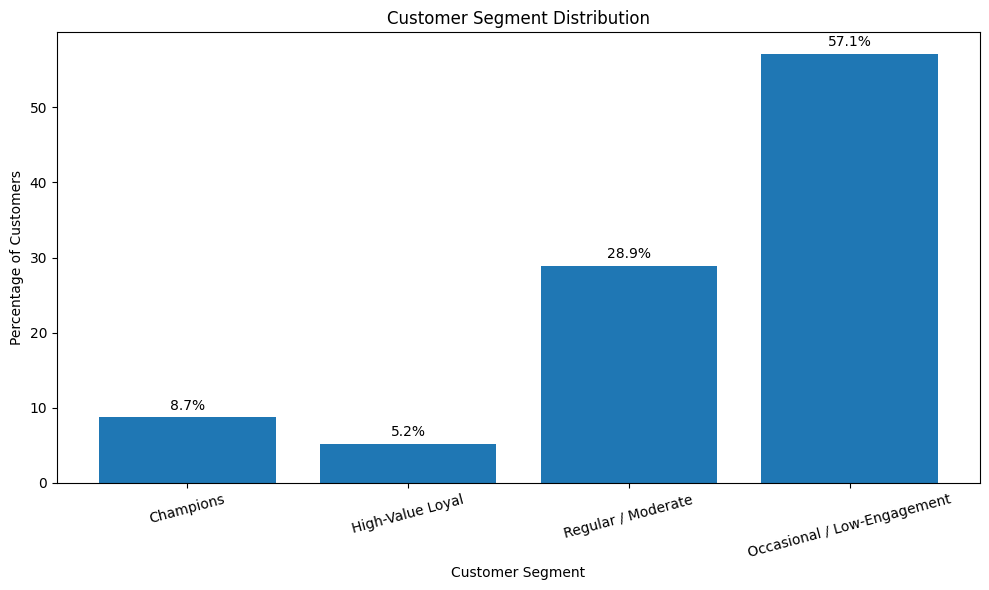

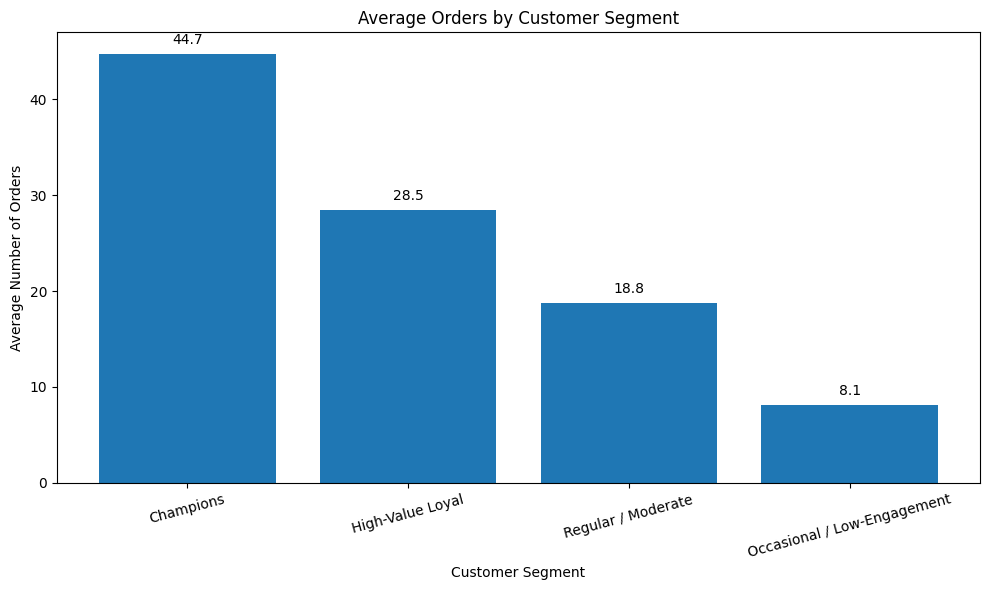

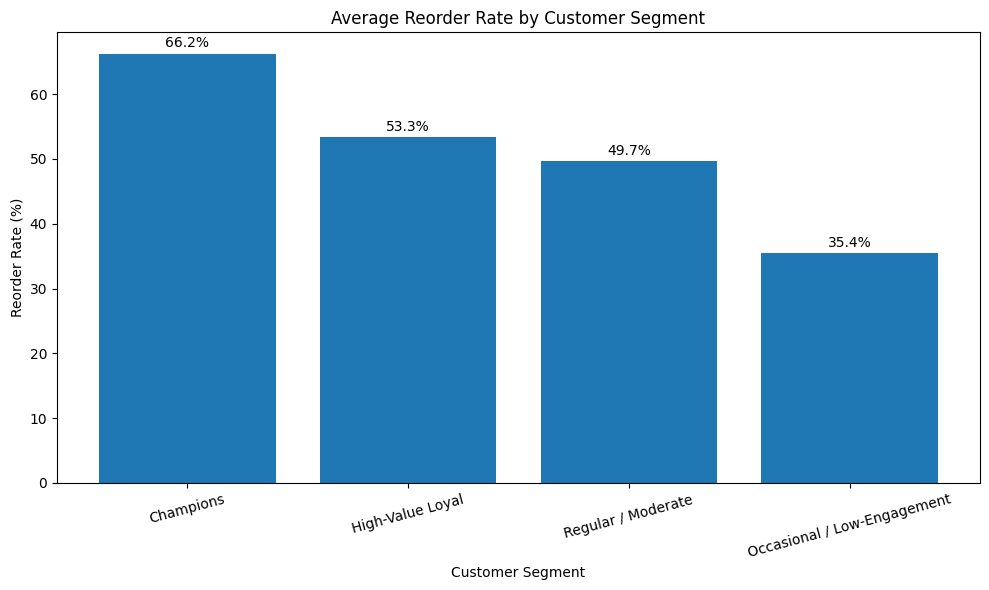


FINAL VISUALIZATIONS COMPLETED


In [48]:
# ============================================================
# STEP 36: FINAL CUSTOMER SEGMENT VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 80)
print("FINAL CUSTOMER SEGMENT VISUALIZATIONS")
print("=" * 80)

# ------------------------------------------------------------
# Business order
# ------------------------------------------------------------

business_order = [
    "Champions / Most Loyal Customers",
    "High-Value Loyal Customers",
    "Regular / Moderate Customers",
    "Occasional / Low-Engagement Customers"
]

plot_df = final_segment_summary.copy()

plot_df["final_segment"] = pd.Categorical(
    plot_df["final_segment"],
    categories=business_order,
    ordered=True
)

plot_df = plot_df.sort_values("final_segment")

# Short labels for charts
short_labels = [
    "Champions",
    "High-Value Loyal",
    "Regular / Moderate",
    "Occasional / Low-Engagement"
]

# ------------------------------------------------------------
# CHART 1 — CUSTOMER SEGMENT SIZE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    short_labels,
    plot_df["Percentage"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=15)

for i, value in enumerate(plot_df["Percentage"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CHART 2 — ORDERS BY SEGMENT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    short_labels,
    plot_df["Avg_Orders"]
)

plt.title("Average Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.xticks(rotation=15)

for i, value in enumerate(plot_df["Avg_Orders"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CHART 3 — REORDER RATE BY SEGMENT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

reorder_pct = plot_df["Avg_Reorder_Rate"] * 100

plt.bar(
    short_labels,
    reorder_pct
)

plt.title("Average Reorder Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Reorder Rate (%)")
plt.xticks(rotation=15)

for i, value in enumerate(reorder_pct):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("FINAL VISUALIZATIONS COMPLETED")
print("=" * 80)

# STEP 36 — FINAL CUSTOMER SEGMENT VISUALIZATIONS

## Purpose

The final visualizations present the business-facing customer segments identified through K-Means clustering. The clusters are arranged in business order from the most loyal/high-value customers to the least engaged customers.

These visualizations focus on three key business indicators:

1. Customer segment size
2. Average number of orders
3. Average reorder rate

---

## 1. Customer Segment Distribution

The customer base is distributed across four business-facing segments:

| Customer Segment | Customers | Percentage |
|---|---:|---:|
| Champions / Most Loyal Customers | 4,367 | 8.7% |
| High-Value Loyal Customers | 2,619 | 5.2% |
| Regular / Moderate Customers | 14,448 | 28.9% |
| Occasional / Low-Engagement Customers | 28,566 | 57.1% |

### Interpretation

The **Occasional / Low-Engagement Customers** segment is the largest segment, representing **57.1% of the customer base**. This indicates a significant opportunity for customer reactivation and engagement.

The **Champions / Most Loyal Customers** represent only **8.7%** of customers, but they are the most valuable and engaged segment based on their purchasing behavior.

---

## 2. Average Orders by Customer Segment

The average number of orders differs substantially across the four segments:

| Customer Segment | Average Orders |
|---|---:|
| Champions / Most Loyal Customers | 44.7 |
| High-Value Loyal Customers | 28.5 |
| Regular / Moderate Customers | 18.8 |
| Occasional / Low-Engagement Customers | 8.1 |

### Interpretation

Champions have the highest average number of orders at **44.7**, while Occasional / Low-Engagement Customers have only **8.1** average orders.

This shows a clear difference in purchasing frequency between the customer segments.

---

## 3. Average Reorder Rate by Customer Segment

The average reorder rate also follows a clear pattern:

| Customer Segment | Average Reorder Rate |
|---|---:|
| Champions / Most Loyal Customers | 66.2% |
| High-Value Loyal Customers | 53.3% |
| Regular / Moderate Customers | 49.7% |
| Occasional / Low-Engagement Customers | 35.4% |

### Interpretation

The **Champions / Most Loyal Customers** have the highest reorder rate at **66.2%**, indicating strong repeat-purchasing behavior.

The **Occasional / Low-Engagement Customers** have the lowest reorder rate at **35.4%**, highlighting them as the primary segment for reactivation and engagement initiatives.

---

## 4. Overall Business Interpretation

The three visualizations collectively demonstrate a clear behavioral distinction between the customer segments.

- **Champions / Most Loyal Customers:** Highest purchase frequency and reorder rate; focus on retention and increasing customer lifetime value.
- **High-Value Loyal Customers:** Strong purchasing behavior; focus on strengthening loyalty and cross-selling.
- **Regular / Moderate Customers:** Moderate engagement; focus on increasing purchase frequency and encouraging repeat purchases.
- **Occasional / Low-Engagement Customers:** Largest segment with the lowest engagement; focus on targeted reactivation and win-back campaigns.

### Key Insight

> The customer base is heterogeneous, with substantial differences in purchasing frequency and loyalty. Therefore, a uniform marketing strategy may not be equally effective across all customers. Segment-specific marketing strategies can be designed based on the behavioral characteristics identified through clustering.

---

## Step 36 Conclusion

The final visualizations successfully translate the K-Means clustering results into **business-facing customer segments** and provide a clear basis for differentiated marketing strategies.